# Helsinki & Espoo City Bikes: Network Analysis Notebook

This notebook implements the network-analysis workflow inspired by the Medium article (centrality and community detection), and extends it with additional exploratory directions useful for the research plan:

1. Directed OD graph construction from trip flows
2. Centrality analysis (degree, betweenness, closeness, PageRank, eigenvector)
3. Community detection (Louvain + optional Fluid communities)
4. Temporal stability of community structure
5. Additional exploration: resilience under hub failures, cross-city edge mixing

The graph views used in forecasting (SD, DE, DC, ATD) are static in the plan baseline; this notebook focuses on **analysis/interpretation**, not dynamic graph generation for training.

In [1]:
from __future__ import annotations

from pathlib import Path
import math

import numpy as np
import pandas as pd
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

_candidates = [Path.cwd().resolve(), Path('.').resolve()]
PROJECT_ROOT = next((
    ancestor
    for base in _candidates
    for ancestor in (base, *base.parents)
    if (ancestor / 'data' / 'prepared' / 'splits' / 'train' / 'train.csv').exists()
    or (ancestor / 'data' / 'prepared' / 'merged' / 'trips_merged.csv').exists()
), next((
    ancestor
    for base in _candidates
    for ancestor in (base, *base.parents)
    if (ancestor / 'data' / 'train' / 'train.csv').exists()
    or (ancestor / 'data' / 'merged' / 'trips_merged.csv').exists()
), next((
    ancestor
    for base in _candidates
    for ancestor in (base, *base.parents)
    if (ancestor / 'data').exists()
), Path('.').resolve())))

DATA_DIR = PROJECT_ROOT / 'data'
PRIMARY_DIR = DATA_DIR / 'primary'
PREPARED_DIR = DATA_DIR / 'prepared'
ARTIFACTS_DIR = DATA_DIR / 'artifacts'

TRAIN_PATH = PREPARED_DIR / 'splits' / 'train' / 'train.csv'
VAL_PATH = PREPARED_DIR / 'splits' / 'validation' / 'validation.csv'
TEST_PATH = PREPARED_DIR / 'splits' / 'test' / 'test.csv'
MERGED_PATH = PREPARED_DIR / 'merged' / 'trips_merged.csv'
NETWORK_OUT_DIR = ARTIFACTS_DIR / 'network' / 'notebook'
NETWORK_OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_SCHEMA_OVERRIDES = {
    'departure_id': pl.String,
    'return_id': pl.String,
    'departure_name': pl.String,
    'return_name': pl.String,
}

RANDOM_STATE = 42
APPROX_BETWEENNESS = True
BETWEENNESS_SAMPLE_K = 200
MIN_FLOW = 1

In [2]:
FIG_DIR = NETWORK_OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})


def save_fig(filename: str):
    out = FIG_DIR / filename
    plt.savefig(out, bbox_inches='tight')
    return out


print(f'Figure output directory: {FIG_DIR}')

Figure output directory: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures


In [3]:
def load_trips() -> pl.DataFrame:
    candidates = [TRAIN_PATH, MERGED_PATH]
    for path in candidates:
        if path.exists():
            df = pl.read_csv(path, try_parse_dates=True, schema_overrides=CSV_SCHEMA_OVERRIDES)
            print(f'Loaded: {path} ({df.height:,} rows, {df.width} cols)')
            return df
    raise FileNotFoundError('No train.csv or trips_merged.csv found. Run prepare_data.py first.')


def preprocess_trips(df: pl.DataFrame) -> pl.DataFrame:
    required = ['departure_name', 'return_name', 'departure']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    out = (
        df
        .with_columns([
            pl.col('departure_name').cast(pl.String, strict=False).str.strip_chars().alias('departure_name'),
            pl.col('return_name').cast(pl.String, strict=False).str.strip_chars().alias('return_name'),
            pl.col('departure').cast(pl.String, strict=False).str.strptime(pl.Datetime, strict=False).alias('departure_ts'),
        ])
        .drop_nulls(['departure_name', 'return_name', 'departure_ts'])
    )

    if 'city' not in out.columns and '_year' in out.columns:
        pass

    return out


trips = preprocess_trips(load_trips())
print(trips.select([
    pl.min('departure_ts').alias('min_departure_ts'),
    pl.max('departure_ts').alias('max_departure_ts'),
]))

Loaded: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\prepared\splits\train\train.csv (14,445,965 rows, 16 cols)
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_departure_ts    ┆ max_departure_ts    │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2016-05-02 09:31:00 ┆ 2021-09-30 23:58:41 │
└─────────────────────┴─────────────────────┘


## Build Directed OD Graph

In [4]:
def build_od_flow(df: pl.DataFrame, min_flow: int = 1) -> pl.DataFrame:
    flow = (
        df
        .group_by(['departure_name', 'return_name'])
        .len()
        .rename({'len': 'flow'})
        .filter(pl.col('flow') >= min_flow)
    )
    return flow


def build_graph(flow_df: pl.DataFrame) -> nx.DiGraph:
    g = nx.DiGraph()
    for row in flow_df.iter_rows(named=True):
        src = row['departure_name']
        dst = row['return_name']
        if src == dst:
            continue
        weight = float(row['flow'])
        g.add_edge(src, dst, flow=weight, cost=1.0 / max(weight, 1e-9))
    return g


flow_df = build_od_flow(trips, min_flow=MIN_FLOW)
G = build_graph(flow_df)

print(f'Nodes: {G.number_of_nodes():,}')
print(f'Edges: {G.number_of_edges():,}')
print(f'Total OD flow represented: {int(flow_df["flow"].sum()):,}')

Nodes: 449
Edges: 80,382
Total OD flow represented: 14,445,965


In [5]:
density = nx.density(G)
wcc = list(nx.weakly_connected_components(G))
largest_wcc = max((len(c) for c in wcc), default=0)

print(f'Density: {density:.6f}')
print(f'Weakly connected components: {len(wcc)}')
print(f'Largest WCC size: {largest_wcc:,}')

Density: 0.399608
Weakly connected components: 1
Largest WCC size: 449


## Centrality Analysis

In [6]:
UG = G.to_undirected()

out_degree = dict(G.out_degree())
in_degree = dict(G.in_degree())
out_strength = dict(G.out_degree(weight='flow'))
in_strength = dict(G.in_degree(weight='flow'))

if APPROX_BETWEENNESS:
    k = min(BETWEENNESS_SAMPLE_K, max(10, UG.number_of_nodes() // 2))
    betweenness = nx.betweenness_centrality(UG, k=k, seed=RANDOM_STATE, weight='cost', normalized=True)
else:
    betweenness = nx.betweenness_centrality(UG, weight='cost', normalized=True)

closeness = nx.closeness_centrality(UG, distance='cost')
pagerank = nx.pagerank(G, weight='flow')

try:
    eigenvector = nx.eigenvector_centrality(UG, weight='flow', max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    eigenvector = {n: np.nan for n in G.nodes()}

centrality_df = pd.DataFrame({
    'station_name': list(G.nodes()),
    'out_degree': [out_degree.get(n, 0) for n in G.nodes()],
    'in_degree': [in_degree.get(n, 0) for n in G.nodes()],
    'out_strength': [out_strength.get(n, 0.0) for n in G.nodes()],
    'in_strength': [in_strength.get(n, 0.0) for n in G.nodes()],
    'betweenness': [betweenness.get(n, 0.0) for n in G.nodes()],
    'closeness': [closeness.get(n, 0.0) for n in G.nodes()],
    'pagerank': [pagerank.get(n, 0.0) for n in G.nodes()],
    'eigenvector': [eigenvector.get(n, np.nan) for n in G.nodes()],
})

centrality_df = centrality_df.sort_values('pagerank', ascending=False).reset_index(drop=True)
centrality_df.head(15)

,station_name,out_degree,in_degree,out_strength,in_strength,betweenness,closeness,pagerank,eigenvector
0,Itämerentori,299,308,336039.0,338333.0,0.244821,161.440210,0.013633,0.353722
1,Töölönlahdenkatu,297,299,260328.0,261945.0,0.132405,161.010579,0.010572,0.280767
2,Kamppi (M),292,289,214924.0,208856.0,0.007105,158.420505,0.008299,0.223132
3,Ympyrätalo,299,302,190742.0,195583.0,0.016672,161.843994,0.008237,0.159231
4,Suomenlahdentie,157,146,62999.0,65649.0,0.021644,140.815471,0.008228,0.000672
5,Kalasatama (M),276,282,139210.0,144512.0,0.437534,163.798432,0.008009,0.068559
6,Rautatientori / länsi,286,287,186421.0,190478.0,0.139905,162.101038,0.007841,0.171135
7,Rautatientori / itä,300,281,171295.0,174311.0,0.027718,161.748215,0.007271,0.151263
8,Sörnäinen (M),287,299,155498.0,149751.0,0.115895,162.372627,0.006934,0.093578
9,Arabian kauppakeskus,272,287,112163.0,117233.0,0.381505,163.608268,0.006873,0.050417


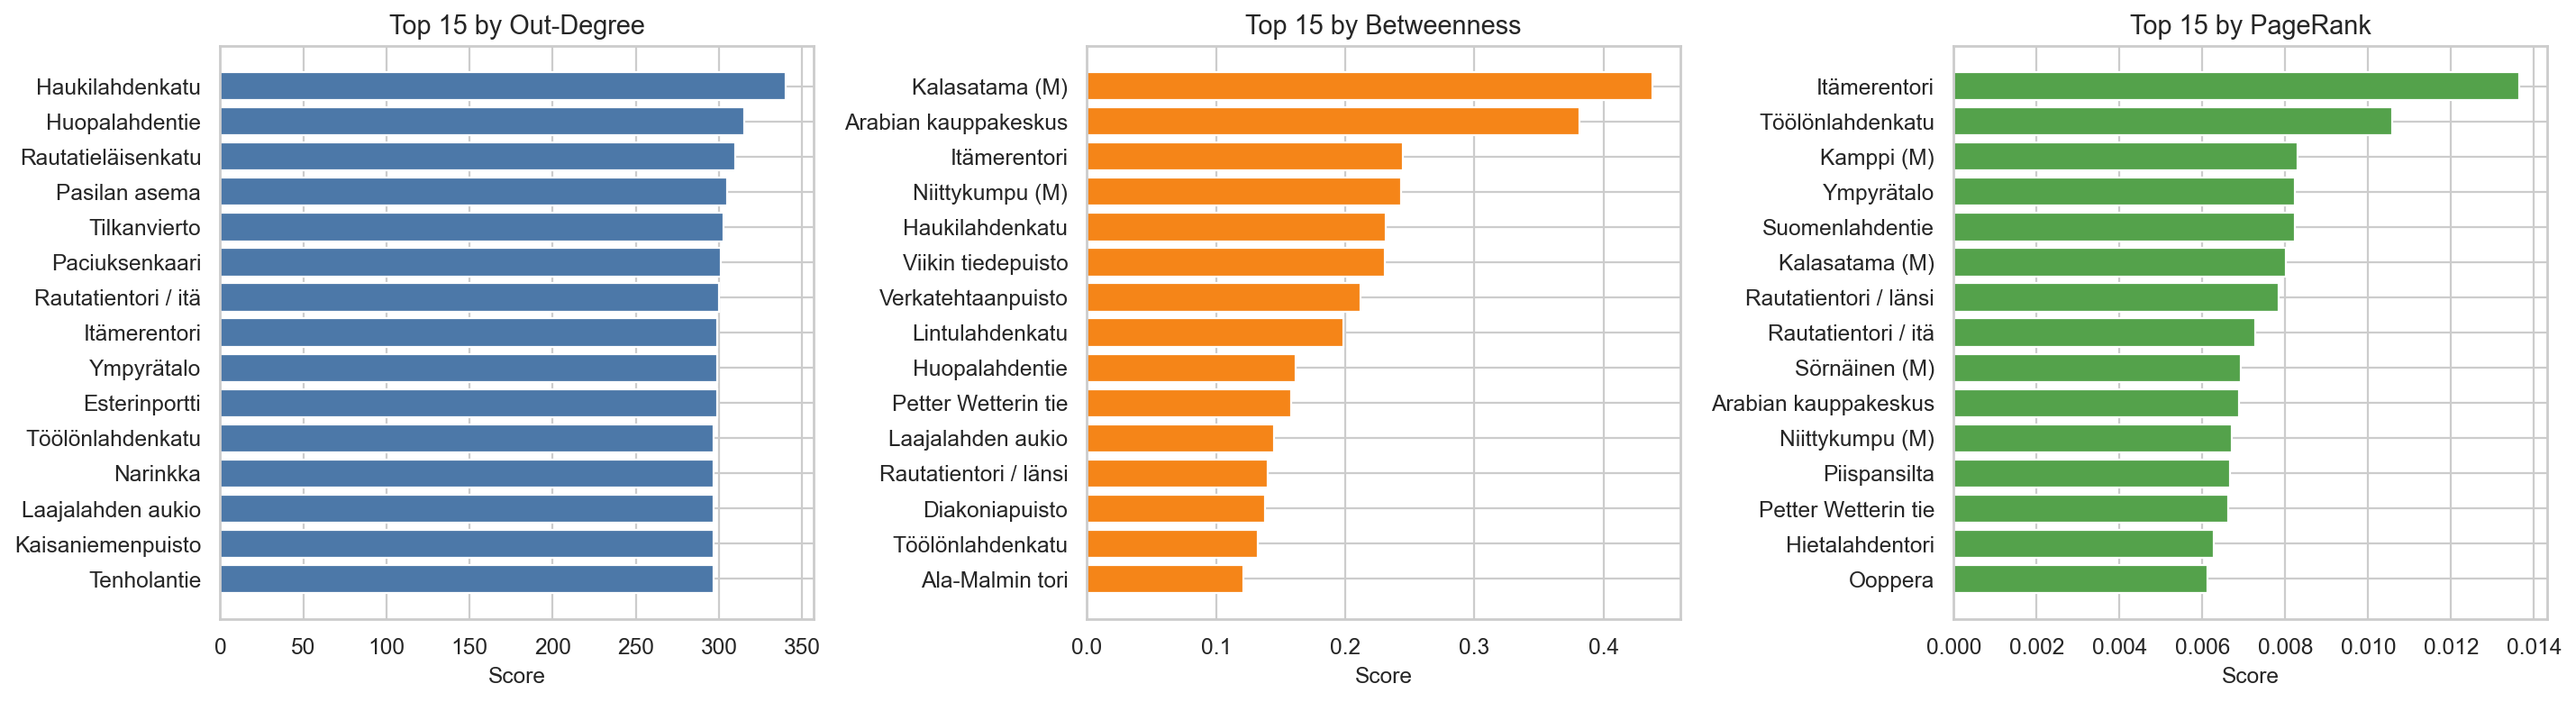

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_deg = centrality_df.nlargest(15, 'out_degree').iloc[::-1]
axes[0].barh(top_deg['station_name'], top_deg['out_degree'], color='#4C78A8')
axes[0].set_title('Top 15 by Out-Degree')

top_bw = centrality_df.nlargest(15, 'betweenness').iloc[::-1]
axes[1].barh(top_bw['station_name'], top_bw['betweenness'], color='#F58518')
axes[1].set_title('Top 15 by Betweenness')

top_pr = centrality_df.nlargest(15, 'pagerank').iloc[::-1]
axes[2].barh(top_pr['station_name'], top_pr['pagerank'], color='#54A24B')
axes[2].set_title('Top 15 by PageRank')

for ax in axes:
    ax.set_xlabel('Score')

plt.tight_layout()
plt.show()

## Community Detection (Louvain + Optional Fluid)

In [8]:
def aggregate_to_undirected_weighted(graph: nx.DiGraph) -> nx.Graph:
    ug = nx.Graph()
    for u, v, data in graph.edges(data=True):
        w = float(data.get('flow', 0.0))
        if w <= 0:
            continue
        if ug.has_edge(u, v):
            ug[u][v]['weight'] += w
        else:
            ug.add_edge(u, v, weight=w)
    return ug


UG_flow = aggregate_to_undirected_weighted(G)
louvain_communities = nx.community.louvain_communities(UG_flow, weight='weight', seed=RANDOM_STATE, resolution=1.0)
louvain_modularity = nx.community.modularity(UG_flow, louvain_communities, weight='weight')

louvain_map = {}
for cid, nodes in enumerate(louvain_communities):
    for n in nodes:
        louvain_map[n] = cid

print(f'Louvain communities: {len(louvain_communities)}')
print(f'Louvain modularity: {louvain_modularity:.4f}')

Louvain communities: 6
Louvain modularity: 0.3997


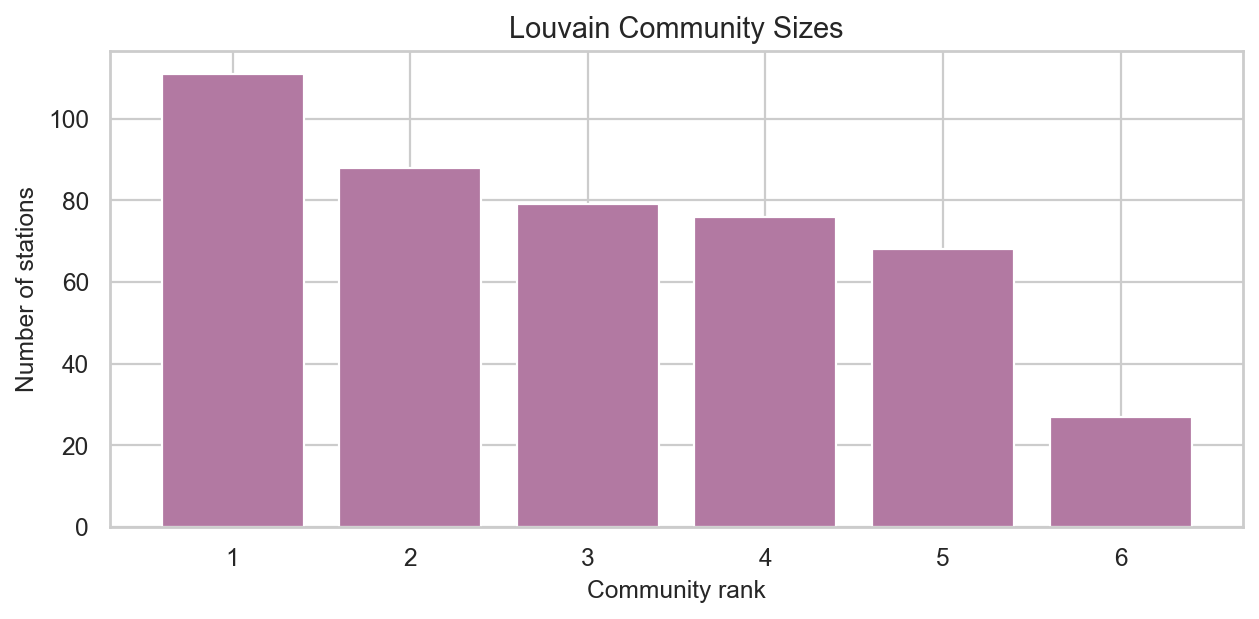

[111, 88, 79, 76, 68, 27]

In [9]:
community_sizes = sorted([len(c) for c in louvain_communities], reverse=True)
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(community_sizes) + 1), community_sizes, color='#B279A2')
plt.title('Louvain Community Sizes')
plt.xlabel('Community rank')
plt.ylabel('Number of stations')
plt.tight_layout()
plt.show()

community_sizes[:10]

### Resolution Sweep: Choosing K for Inference

The K=5 partition above is the **modelling community** used by the STGNN (large enough that each community has adequate demand signal).  
For **statistical inference** (cluster-aware permutation test in `rq_hypothesis_tests.py`) we need a *separate* question: how many independent spatial units does the network support?

With K=5, the minimum achievable cluster-permutation p-value is 2/2^K ≈ 0.063.  
After Holm correction (family size 3 for RQ1/RQ2, 2 for RQ3) that floor becomes 0.19 / 0.13 — both above α=0.05.  
The test **cannot** reject H₀ regardless of effect size as long as K < 7.

The cell below sweeps Louvain `resolution` on the same OD-flow graph (`UG_flow`) and records:
- K (number of communities)
- Louvain modularity
- p_cluster floor = 2 / 2^K
- p_holm floor (Holm × family size 3) — the practical constraint

A target of **K ≥ 10** gives p_cluster_floor ≈ 0.002 and p_holm_floor ≈ 0.006, comfortably below α=0.05 with margin.  
The chosen partition is saved as `inference_communities.csv` in the same output directory as `communities.csv`.

 resolution  K  modularity  largest_community  smallest_community  p_cluster_floor  p_holm_floor_family3  clears_alpha_0.05
        1.0  6      0.3997                111                  27         0.031250              0.093750              False
        1.2  7      0.3975                 94                  33         0.015625              0.046875               True
        1.4 10      0.3848                 78                  11         0.001953              0.005859               True
        1.6 10      0.3662                118                  11         0.001953              0.005859               True
        1.8 11      0.3499                 81                   9         0.000977              0.002930               True
        2.0 15      0.3246                 81                   3         0.000061              0.000183               True
        2.5 21      0.2981                 84                   1         0.000001              0.000003               True
        

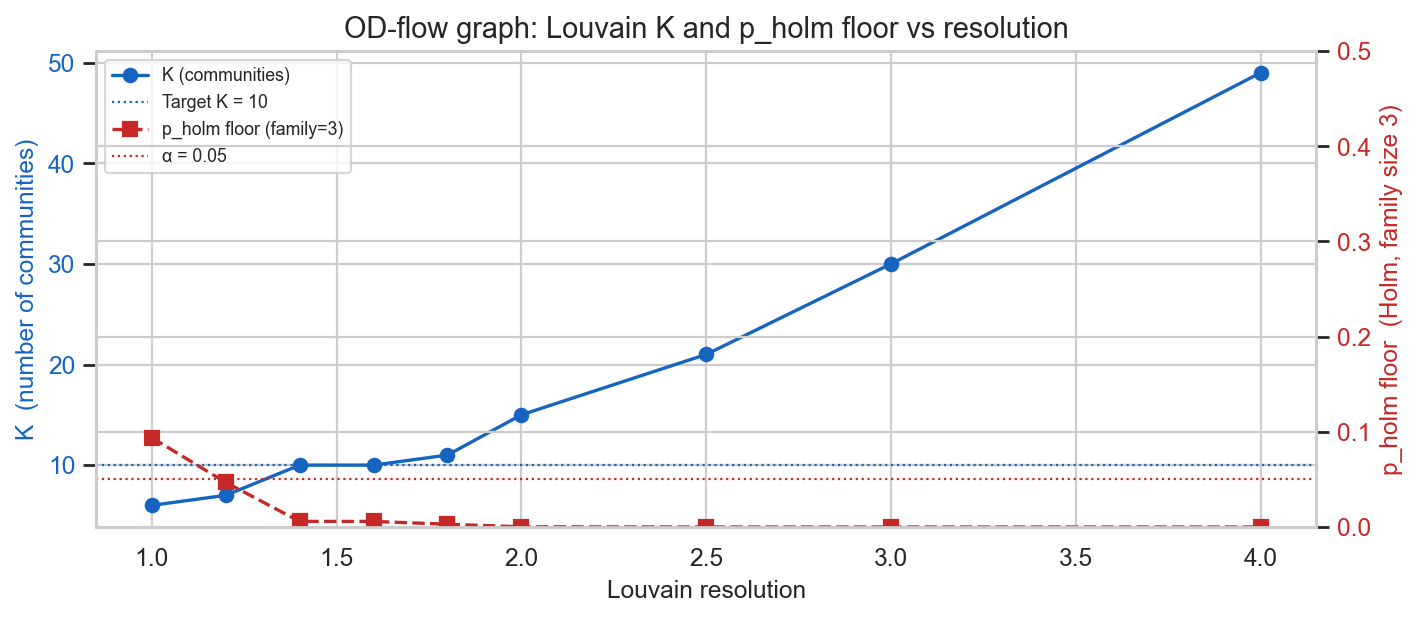

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\louvain_resolution_sweep_odflow.png

Chosen inference resolution: 1.4  (K=10, modularity=0.3848, p_holm_floor=0.005859)
Saved inference communities (10 communities, 449 stations): C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\inference_communities.csv

Pass this file to rq_hypothesis_tests.py via:
  --communities C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\inference_communities.csv


In [10]:
# ── Resolution sweep on the OD-flow graph ────────────────────────────────────
# UG_flow is already defined above (undirected, weighted by OD trip counts).
# We sweep resolution values and record K, modularity, and the p-value floor
# that the cluster-aware permutation test can never go below.

INFERENCE_RESOLUTIONS = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 4.0]
HOLM_FAMILY_SIZE = 3        # RQ1 and RQ2 (most conservative)
INFERENCE_TARGET_K = 10     # minimum K for comfortable Holm headroom

sweep_rows = []
for res in INFERENCE_RESOLUTIONS:
    comms = nx.community.louvain_communities(
        UG_flow, weight='weight', seed=RANDOM_STATE, resolution=res
    )
    K = len(comms)
    mod = nx.community.modularity(UG_flow, comms, weight='weight')
    sizes = sorted([len(c) for c in comms], reverse=True)
    p_floor = 2.0 / (2 ** K)                        # minimum cluster-perm p-value
    p_holm_floor = min(1.0, HOLM_FAMILY_SIZE * p_floor)  # after Holm
    sweep_rows.append({
        'resolution': res,
        'K': K,
        'modularity': round(mod, 4),
        'largest_community': sizes[0],
        'smallest_community': sizes[-1],
        'p_cluster_floor': round(p_floor, 6),
        'p_holm_floor_family3': round(p_holm_floor, 6),
        'clears_alpha_0.05': p_holm_floor < 0.05,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

# ── Save the sweep table ──────────────────────────────────────────────────────
sweep_csv = NETWORK_OUT_DIR / 'louvain_resolution_sweep_odflow.csv'
sweep_df.to_csv(sweep_csv, index=False)
print(f'\nSaved: {sweep_csv}')

# ── Plot: K and p_holm_floor vs resolution ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(sweep_df['resolution'], sweep_df['K'], 'o-', color='#1565C0', label='K (communities)')
ax1.axhline(INFERENCE_TARGET_K, color='#1565C0', linestyle=':', linewidth=1,
            label=f'Target K = {INFERENCE_TARGET_K}')
ax1.set_xlabel('Louvain resolution')
ax1.set_ylabel('K  (number of communities)', color='#1565C0')
ax1.tick_params(axis='y', labelcolor='#1565C0')

ax2.plot(sweep_df['resolution'], sweep_df['p_holm_floor_family3'],
         's--', color='#C62828', label='p_holm floor (family=3)')
ax2.axhline(0.05, color='#C62828', linestyle=':', linewidth=1, label='α = 0.05')
ax2.set_ylabel('p_holm floor  (Holm, family size 3)', color='#C62828')
ax2.tick_params(axis='y', labelcolor='#C62828')
ax2.set_ylim(0, 0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.set_title('OD-flow graph: Louvain K and p_holm floor vs resolution')
plt.tight_layout()
fig_path = FIG_DIR / 'louvain_resolution_sweep_odflow.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

# ── Choose inference resolution and save communities ──────────────────────────
# Select the smallest resolution that achieves K >= INFERENCE_TARGET_K.
eligible = sweep_df[sweep_df['K'] >= INFERENCE_TARGET_K]
if eligible.empty:
    print(f'\nWARNING: no resolution in sweep achieved K >= {INFERENCE_TARGET_K}. '
          'Increase INFERENCE_RESOLUTIONS upper bound.')
    INFERENCE_RESOLUTION_CHOSEN = None
else:
    chosen_row = eligible.iloc[0]
    INFERENCE_RESOLUTION_CHOSEN = float(chosen_row['resolution'])
    print(f'\nChosen inference resolution: {INFERENCE_RESOLUTION_CHOSEN}  '
          f'(K={int(chosen_row["K"])}, '
          f'modularity={chosen_row["modularity"]}, '
          f'p_holm_floor={chosen_row["p_holm_floor_family3"]})')

    inference_comms = nx.community.louvain_communities(
        UG_flow, weight='weight', seed=RANDOM_STATE, resolution=INFERENCE_RESOLUTION_CHOSEN
    )
    inference_map_rows = [
        {'station_name': station, 'community': f'inf_{cid}'}
        for cid, nodes in enumerate(inference_comms)
        for station in nodes
    ]
    inference_communities_df = (
        pd.DataFrame(inference_map_rows)
        .sort_values(['community', 'station_name'])
        .reset_index(drop=True)
    )
    inference_csv = NETWORK_OUT_DIR / 'inference_communities.csv'
    inference_communities_df.to_csv(inference_csv, index=False)
    print(f'Saved inference communities ({len(inference_comms)} communities, '
          f'{len(inference_communities_df)} stations): {inference_csv}')
    print('\nPass this file to rq_hypothesis_tests.py via:')
    print(f'  --communities {inference_csv}')

In [11]:
# Optional: Fluid communities for comparison with Louvain (if graph is connected).
fluid_results = None
try:
    if nx.is_connected(UG_flow):
        k = min(5, max(2, len(louvain_communities)))
        fluid_communities = list(nx.community.asyn_fluidc(UG_flow, k=k, seed=RANDOM_STATE))

        fluid_map = {}
        for cid, nodes in enumerate(fluid_communities):
            for n in nodes:
                fluid_map[n] = cid

        shared_nodes = sorted(set(louvain_map).intersection(fluid_map))
        if shared_nodes:
            from sklearn.metrics import normalized_mutual_info_score
            l_labels = [louvain_map[n] for n in shared_nodes]
            f_labels = [fluid_map[n] for n in shared_nodes]
            nmi = normalized_mutual_info_score(l_labels, f_labels)
        else:
            nmi = np.nan

        fluid_results = {'k': k, 'nmi_vs_louvain': float(nmi), 'communities': len(fluid_communities)}
    else:
        fluid_results = {'warning': 'Graph is not connected; fluid communities skipped.'}
except Exception as e:
    fluid_results = {'warning': f'Fluid communities unavailable: {e}'}

fluid_results

{'k': 5, 'nmi_vs_louvain': 0.6139714592567296, 'communities': 5}

## Temporal Community Stability (Promising Extension)

In [12]:
from sklearn.metrics import normalized_mutual_info_score

year_df = trips.with_columns(pl.col('departure_ts').dt.strftime('%Y').alias('year'))
years = sorted(year_df.get_column('year').unique().to_list())
year_partitions = {}

for y in years:
    part = year_df.filter(pl.col('year') == y)
    flow_y = build_od_flow(part, min_flow=MIN_FLOW)
    g_y = build_graph(flow_y)
    ug_y = aggregate_to_undirected_weighted(g_y)
    if ug_y.number_of_edges() == 0 or ug_y.number_of_nodes() == 0:
        continue
    comms = nx.community.louvain_communities(ug_y, weight='weight', seed=RANDOM_STATE, resolution=1.0)
    cmap = {}
    for cid, nodes in enumerate(comms):
        for n in nodes:
            cmap[n] = cid
    year_partitions[y] = cmap

stability_rows = []
for y_prev, y_curr in zip(sorted(year_partitions), sorted(year_partitions)[1:]):
    prev_map = year_partitions[y_prev]
    curr_map = year_partitions[y_curr]
    shared = sorted(set(prev_map).intersection(curr_map))
    if not shared:
        continue
    prev_labels = [prev_map[n] for n in shared]
    curr_labels = [curr_map[n] for n in shared]
    nmi = normalized_mutual_info_score(prev_labels, curr_labels)
    stability_rows.append({'previous_year': y_prev, 'current_year': y_curr, 'nmi': nmi, 'shared_nodes': len(shared)})

stability_df = pd.DataFrame(stability_rows)
stability_df

,previous_year,current_year,nmi,shared_nodes
0,2016,2017,0.615928,46
1,2017,2018,0.712738,141
2,2018,2019,0.751716,243
3,2019,2020,0.805633,336
4,2020,2021,0.795171,341


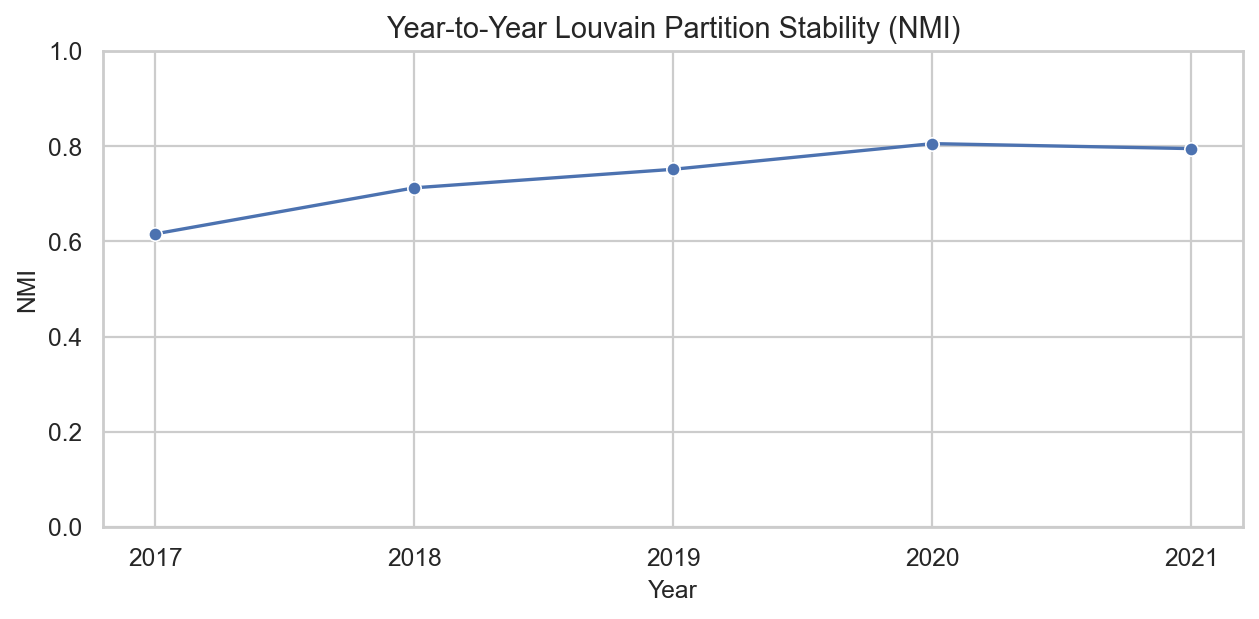

In [13]:
if not stability_df.empty:
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=stability_df, x='current_year', y='nmi', marker='o')
    plt.ylim(0, 1)
    plt.title('Year-to-Year Louvain Partition Stability (NMI)')
    plt.ylabel('NMI')
    plt.xlabel('Year')
    plt.tight_layout()
    plt.show()

## Additional Exploration Directions

In [14]:
# 1) Resilience analysis: remove top-PageRank stations and inspect giant component size.
def giant_component_ratio(graph: nx.DiGraph) -> float:
    if graph.number_of_nodes() == 0:
        return 0.0
    ug = graph.to_undirected()
    if ug.number_of_nodes() == 0:
        return 0.0
    gcc = max(nx.connected_components(ug), key=len)
    return len(gcc) / graph.number_of_nodes()

ranked_nodes = centrality_df['station_name'].tolist()
fractions = [0.0, 0.01, 0.02, 0.05, 0.1]
resilience_rows = []

for frac in fractions:
    g_copy = G.copy()
    k_remove = int(math.floor(frac * G.number_of_nodes()))
    remove_nodes = ranked_nodes[:k_remove]
    g_copy.remove_nodes_from(remove_nodes)
    resilience_rows.append({'removed_fraction': frac, 'giant_component_ratio': giant_component_ratio(g_copy)})

resilience_df = pd.DataFrame(resilience_rows)
resilience_df

,removed_fraction,giant_component_ratio
0,0.00,1.0
1,0.01,1.0
2,0.02,1.0
3,0.05,1.0
4,0.10,1.0


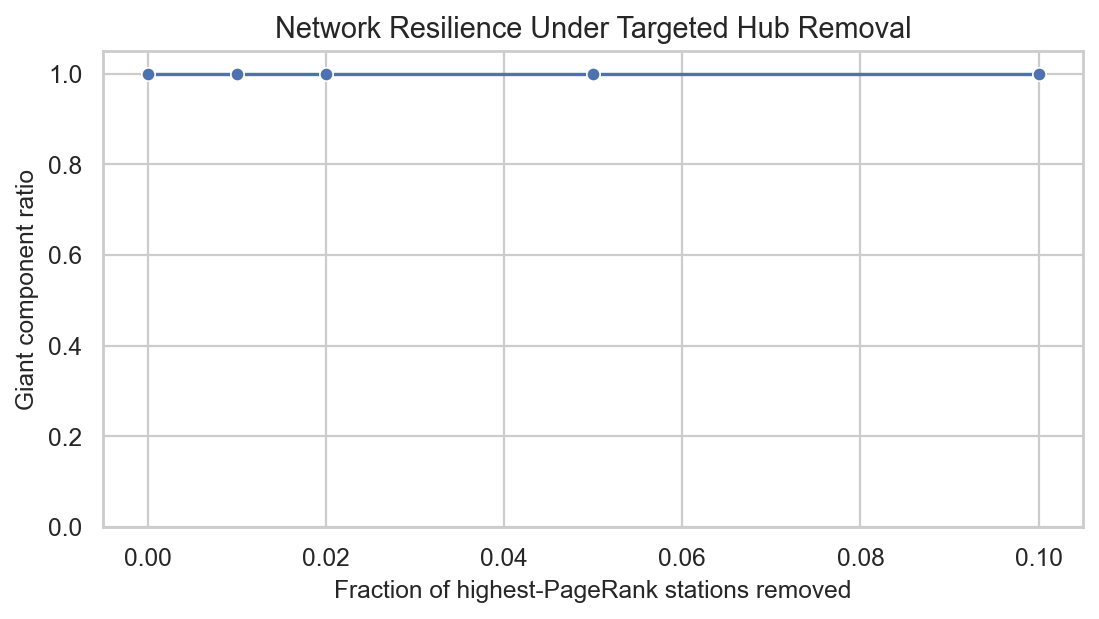

In [15]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=resilience_df, x='removed_fraction', y='giant_component_ratio', marker='o')
plt.title('Network Resilience Under Targeted Hub Removal')
plt.xlabel('Fraction of highest-PageRank stations removed')
plt.ylabel('Giant component ratio')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [16]:
# 2) Cross-city edge mixing (if city metadata available in merged data).
mixing = None
if 'city' in trips.columns:
    city_lookup = (
        trips
        .select(['departure_name', 'city'])
        .drop_nulls(['departure_name', 'city'])
        .unique(subset=['departure_name'], keep='first')
    )
    city_map = dict(zip(city_lookup['departure_name'].to_list(), city_lookup['city'].to_list()))

    rows = []
    for u, v, data in G.edges(data=True):
        cu = city_map.get(u, 'Unknown')
        cv = city_map.get(v, 'Unknown')
        rows.append({'from_city': cu, 'to_city': cv, 'flow': float(data.get('flow', 0.0))})
    mixing = pd.DataFrame(rows).groupby(['from_city', 'to_city'], as_index=False)['flow'].sum()

mixing

## Publication-Ready Figures and Diagnostics

The following section adds publication-oriented visuals and tables that can be used in a paper:

1. Community-to-community flow heatmaps (absolute and normalized)
2. Bridge-vs-hub diagnostics (betweenness vs PageRank)
3. Demand inequality (Lorenz curves + Gini coefficients)
4. Temporal demand signature (hour x weekday)
5. Geographic station map colored by communities

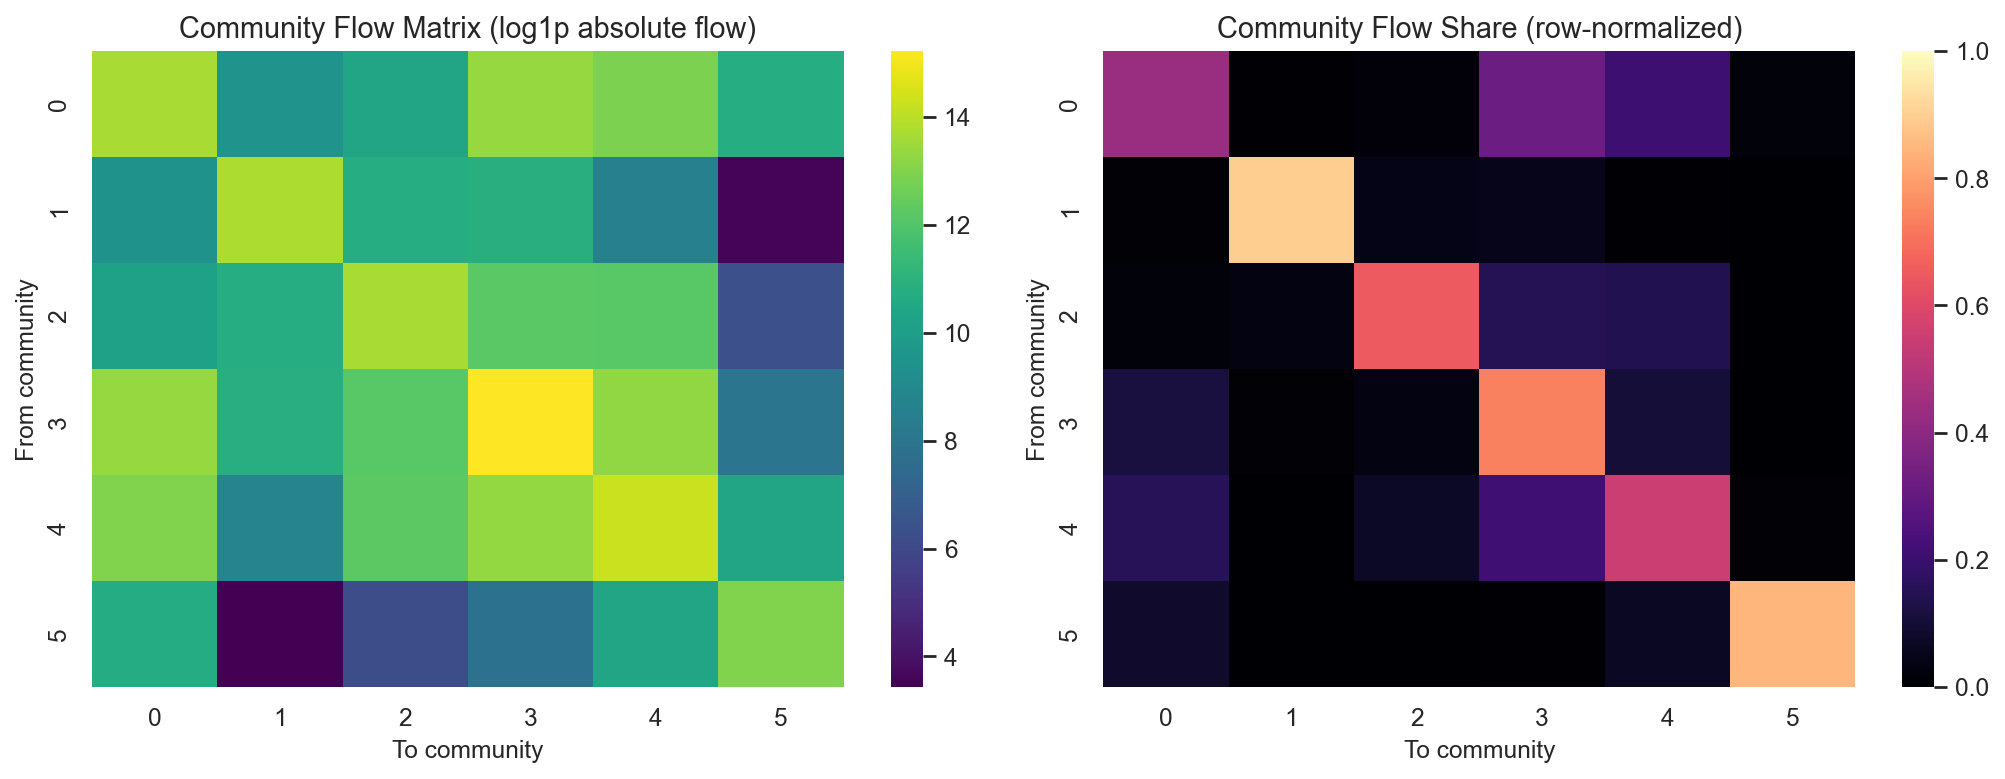

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\community_flow_heatmaps.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\community_flow_matrix.csv


In [17]:
community_flow_rows = []
for u, v, data in G.edges(data=True):
    cu = louvain_map.get(u)
    cv = louvain_map.get(v)
    if cu is None or cv is None:
        continue
    community_flow_rows.append(
        {
            'from_community': int(cu),
            'to_community': int(cv),
            'flow': float(data.get('flow', 0.0)),
        }
    )

community_flow_df = pd.DataFrame(community_flow_rows)
community_flow_matrix = (
    community_flow_df.groupby(['from_community', 'to_community'], as_index=False)['flow']
    .sum()
    .pivot(index='from_community', columns='to_community', values='flow')
    .fillna(0.0)
)

ordered = sorted(community_flow_matrix.index.tolist())
community_flow_matrix = community_flow_matrix.reindex(index=ordered, columns=ordered, fill_value=0.0)
community_flow_share = community_flow_matrix.div(
    community_flow_matrix.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(np.log1p(community_flow_matrix), cmap='viridis', ax=axes[0])
axes[0].set_title('Community Flow Matrix (log1p absolute flow)')
axes[0].set_xlabel('To community')
axes[0].set_ylabel('From community')

sns.heatmap(community_flow_share, cmap='magma', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Community Flow Share (row-normalized)')
axes[1].set_xlabel('To community')
axes[1].set_ylabel('From community')

plt.tight_layout()
community_flow_fig = save_fig('community_flow_heatmaps.png')
plt.show()

community_flow_csv = NETWORK_OUT_DIR / 'community_flow_matrix.csv'
community_flow_matrix.to_csv(community_flow_csv)
print(f'Saved figure: {community_flow_fig}')
print(f'Saved table: {community_flow_csv}')

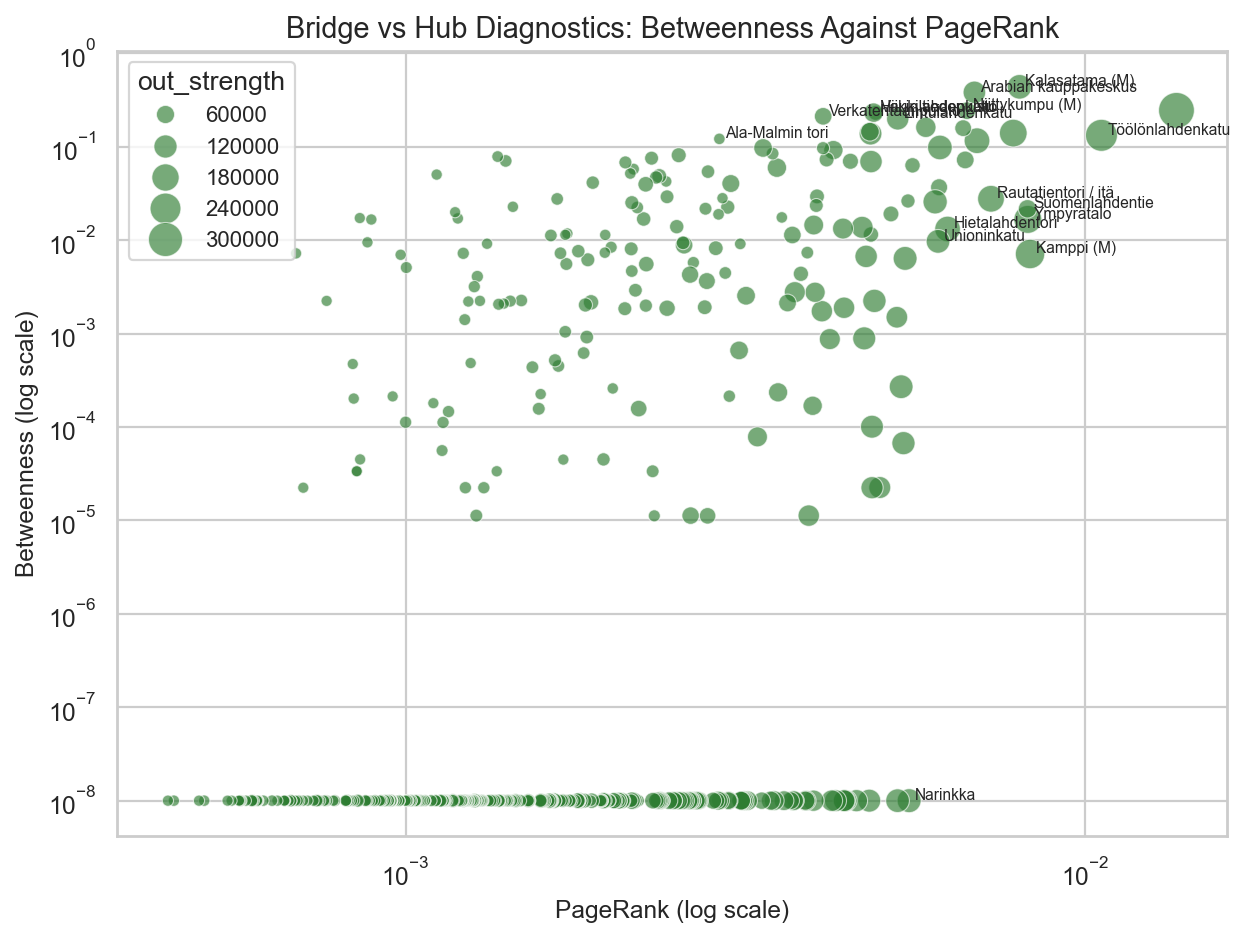

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\bridge_vs_hub_scatter.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\centrality_bridge_vs_hub.csv


In [18]:
diagnostics_df = centrality_df[
    ['station_name', 'pagerank', 'betweenness', 'out_strength', 'in_strength']
].copy()

for col in ['pagerank', 'betweenness', 'out_strength', 'in_strength']:
    diagnostics_df[f'z_{col}'] = (
        diagnostics_df[col] - diagnostics_df[col].mean()
    ) / (diagnostics_df[col].std(ddof=0) + 1e-12)

diagnostics_df['bridge_vs_popularity'] = (
    diagnostics_df['z_betweenness'] - diagnostics_df['z_pagerank']
)
diagnostics_df['pagerank_eps'] = diagnostics_df['pagerank'] + 1e-8
diagnostics_df['betweenness_eps'] = diagnostics_df['betweenness'] + 1e-8

label_df = pd.concat(
    [
        diagnostics_df.nlargest(8, 'bridge_vs_popularity'),
        diagnostics_df.nsmallest(8, 'bridge_vs_popularity'),
    ],
    axis=0,
).drop_duplicates(subset=['station_name'])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=diagnostics_df,
    x='pagerank_eps',
    y='betweenness_eps',
    size='out_strength',
    sizes=(25, 260),
    alpha=0.65,
    color='#2E7D32',
    edgecolor='white',
    linewidth=0.5,
)

for _, row in label_df.iterrows():
    plt.text(
        row['pagerank_eps'] * 1.02,
        row['betweenness_eps'] * 1.02,
        row['station_name'],
        fontsize=7,
    )

plt.xscale('log')
plt.yscale('log')
plt.xlabel('PageRank (log scale)')
plt.ylabel('Betweenness (log scale)')
plt.title('Bridge vs Hub Diagnostics: Betweenness Against PageRank')
plt.tight_layout()
bridge_hub_fig = save_fig('bridge_vs_hub_scatter.png')
plt.show()

disagreement_csv = NETWORK_OUT_DIR / 'centrality_bridge_vs_hub.csv'
diagnostics_df.sort_values('bridge_vs_popularity', ascending=False).to_csv(disagreement_csv, index=False)
print(f'Saved figure: {bridge_hub_fig}')
print(f'Saved table: {disagreement_csv}')

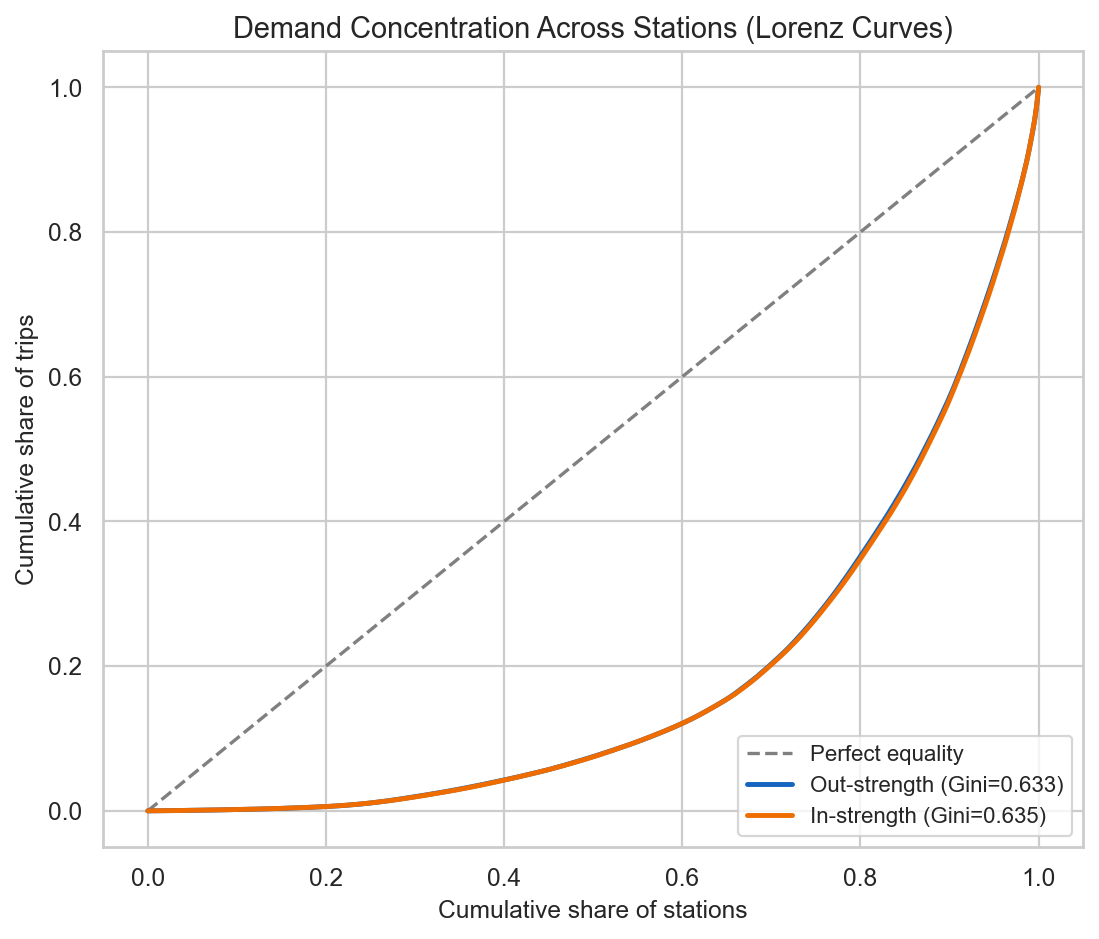

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\demand_inequality_lorenz.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\demand_inequality_lorenz_points.csv
Gini out-strength: 0.6334
Gini in-strength: 0.6354


In [19]:
def lorenz_curve_points(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(values, dtype=float))
    if x.size == 0 or np.isclose(x.sum(), 0.0):
        p = np.linspace(0.0, 1.0, max(2, x.size + 1))
        return p, p
    cum = np.cumsum(x)
    lorenz = np.insert(cum / cum[-1], 0, 0.0)
    population = np.linspace(0.0, 1.0, x.size + 1)
    return population, lorenz


def gini_coefficient(values: np.ndarray) -> float:
    p, l = lorenz_curve_points(values)
    return float(1.0 - 2.0 * np.trapezoid(l, p))


p_out, l_out = lorenz_curve_points(centrality_df['out_strength'].to_numpy())
p_in, l_in = lorenz_curve_points(centrality_df['in_strength'].to_numpy())

gini_out = gini_coefficient(centrality_df['out_strength'].to_numpy())
gini_in = gini_coefficient(centrality_df['in_strength'].to_numpy())

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect equality')
plt.plot(p_out, l_out, color='#1565C0', linewidth=2.2, label=f'Out-strength (Gini={gini_out:.3f})')
plt.plot(p_in, l_in, color='#EF6C00', linewidth=2.2, label=f'In-strength (Gini={gini_in:.3f})')
plt.xlabel('Cumulative share of stations')
plt.ylabel('Cumulative share of trips')
plt.title('Demand Concentration Across Stations (Lorenz Curves)')
plt.legend(loc='lower right')
plt.tight_layout()
lorenz_fig = save_fig('demand_inequality_lorenz.png')
plt.show()

lorenz_csv = NETWORK_OUT_DIR / 'demand_inequality_lorenz_points.csv'
pd.DataFrame(
    {
        'population_share': p_out,
        'out_strength_lorenz': l_out,
        'in_strength_lorenz': np.interp(p_out, p_in, l_in),
    }
).to_csv(lorenz_csv, index=False)

print(f'Saved figure: {lorenz_fig}')
print(f'Saved table: {lorenz_csv}')
print(f'Gini out-strength: {gini_out:.4f}')
print(f'Gini in-strength: {gini_in:.4f}')

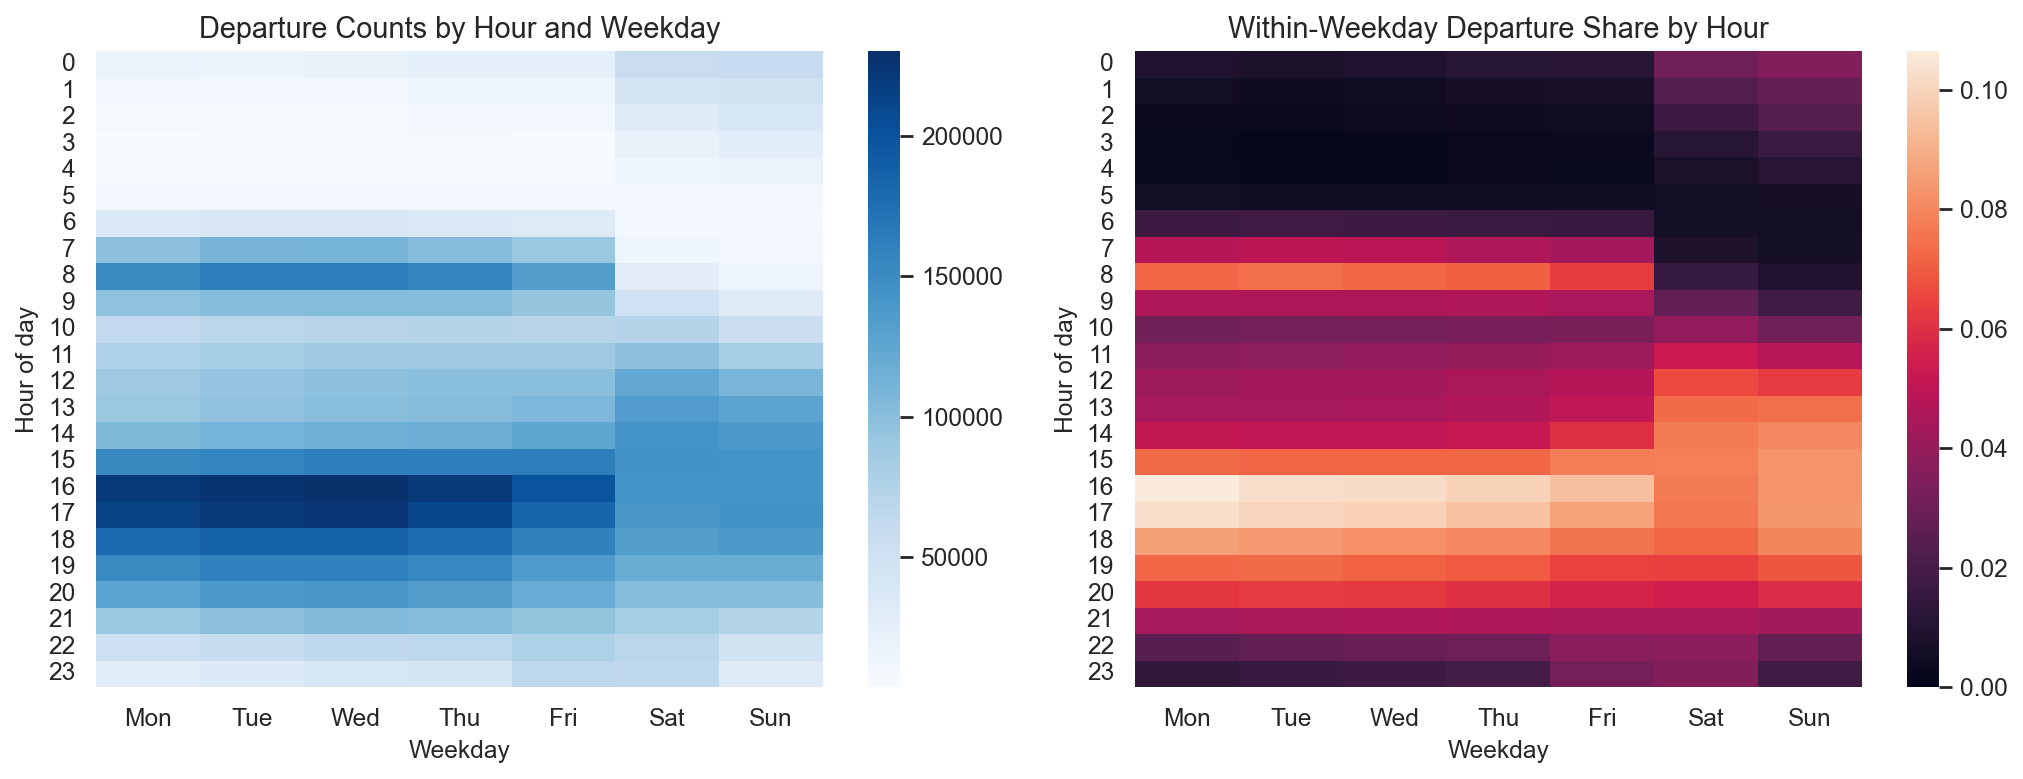

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\temporal_signature_hour_weekday.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\departure_hour_weekday_counts.csv


In [20]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

hour_weekday_pl = (
    trips
    .select([
        pl.col('departure_ts').dt.hour().alias('hour'),
        pl.col('departure_ts').dt.strftime('%a').alias('weekday'),
    ])
    .group_by(['weekday', 'hour'])
    .len()
    .rename({'len': 'trips'})
)
hour_weekday_df = pd.DataFrame(hour_weekday_pl.to_dicts())

hour_weekday_pivot = (
    hour_weekday_df
    .pivot(index='hour', columns='weekday', values='trips')
    .reindex(index=list(range(24)), columns=weekday_order)
    .fillna(0.0)
)
hour_weekday_share = hour_weekday_pivot.div(
    hour_weekday_pivot.sum(axis=0).replace(0, np.nan), axis=1
).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(hour_weekday_pivot, cmap='Blues', ax=axes[0])
axes[0].set_title('Departure Counts by Hour and Weekday')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Hour of day')

sns.heatmap(hour_weekday_share, cmap='rocket', vmin=0, vmax=hour_weekday_share.to_numpy().max(), ax=axes[1])
axes[1].set_title('Within-Weekday Departure Share by Hour')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Hour of day')

plt.tight_layout()
temporal_fig = save_fig('temporal_signature_hour_weekday.png')
plt.show()

temporal_csv = NETWORK_OUT_DIR / 'departure_hour_weekday_counts.csv'
hour_weekday_pivot.to_csv(temporal_csv)
print(f'Saved figure: {temporal_fig}')
print(f'Saved table: {temporal_csv}')

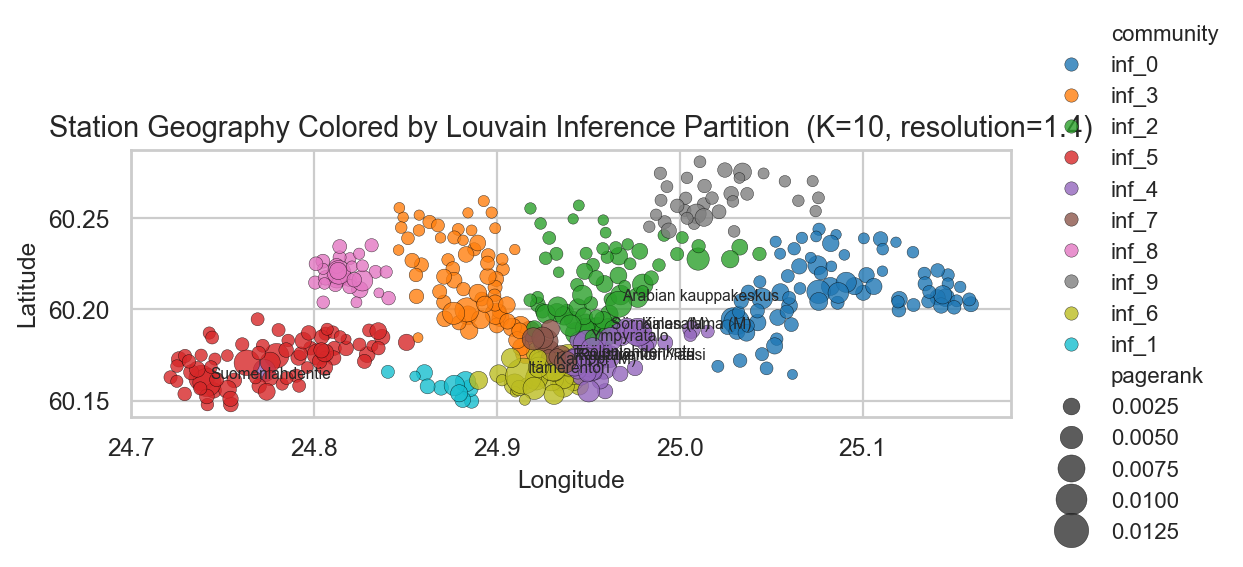

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\community_geographic_map.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\station_community_coordinates.csv


In [21]:
coord_required = {
    'departure_name',
    'departure_latitude',
    'departure_longitude',
    'return_name',
    'return_latitude',
    'return_longitude',
}

if coord_required.issubset(set(trips.columns)):
    dep_coords = trips.select(
        [
            pl.col('departure_name').alias('station_name'),
            pl.col('departure_latitude').cast(pl.Float64).alias('latitude'),
            pl.col('departure_longitude').cast(pl.Float64).alias('longitude'),
        ]
    )
    ret_coords = trips.select(
        [
            pl.col('return_name').alias('station_name'),
            pl.col('return_latitude').cast(pl.Float64).alias('latitude'),
            pl.col('return_longitude').cast(pl.Float64).alias('longitude'),
        ]
    )

    station_coords_pl = (
        pl.concat([dep_coords, ret_coords], how='vertical_relaxed')
        .drop_nulls(['station_name', 'latitude', 'longitude'])
        .group_by('station_name')
        .agg(
            [
                pl.col('latitude').mean().alias('latitude'),
                pl.col('longitude').mean().alias('longitude'),
            ]
        )
    )
    station_coords_df = pd.DataFrame(station_coords_pl.to_dicts())

    # Use the inference-resolution partition (K ≥ INFERENCE_TARGET_K) so the map
    # is consistent with the cluster-aware hypothesis tests.
    if 'inference_communities_df' in dir() or 'inference_communities_df' in vars():
        community_lookup_df = inference_communities_df[['station_name', 'community']].copy()
        k_label = int(community_lookup_df['community'].nunique())
        title_suffix = f'Louvain Inference Partition  (K={k_label}, resolution={INFERENCE_RESOLUTION_CHOSEN})'
    else:
        community_lookup_df = pd.DataFrame(
            [(station, cid) for station, cid in louvain_map.items()],
            columns=['station_name', 'community'],
        )
        title_suffix = 'Louvain Community  (K=5, resolution=1.0)'

    map_df = (
        station_coords_df
        .merge(community_lookup_df, on='station_name', how='left')
        .merge(centrality_df[['station_name', 'pagerank']], on='station_name', how='left')
    )

    n_communities = map_df['community'].nunique()
    palette = 'tab20' if n_communities > 10 else 'tab10'

    plt.figure(figsize=(8, 8))
    sns.scatterplot(
        data=map_df,
        x='longitude',
        y='latitude',
        hue='community',
        size='pagerank',
        sizes=(20, 260),
        alpha=0.8,
        palette=palette,
        linewidth=0.2,
        edgecolor='black',
    )

    for _, row in map_df.nlargest(10, 'pagerank').iterrows():
        plt.text(row['longitude'] + 0.002, row['latitude'] + 0.002, row['station_name'], fontsize=7)

    plt.title(f'Station Geography Colored by {title_suffix}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    community_geo_fig = save_fig('community_geographic_map.png')
    plt.show()

    map_csv = NETWORK_OUT_DIR / 'station_community_coordinates.csv'
    map_df.to_csv(map_csv, index=False)
    print(f'Saved figure: {community_geo_fig}')
    print(f'Saved table: {map_csv}')
else:
    print('Skipping geographic map: coordinate columns are not available in the selected trips dataset.')

## Multi-Graph Comparative Analysis (SD, DE, DC, ATD)

This section compares the precomputed graph views from data/artifacts/graphs/train and answers:

1. How their structural properties differ
2. Whether important stations are stable across graph definitions
3. Whether communities agree across graph definitions
4. How much edge-level agreement exists across graph views

Interpretation note: for comparability, we analyze graph backbones built from the strongest edges in each matrix (quantile filtering).

In [22]:
GRAPH_DIR = ARTIFACTS_DIR / 'graphs' / 'train'
MATRIX_FILES = {
    'SD': GRAPH_DIR / 'SD.npy',
    'DE': GRAPH_DIR / 'DE.npy',
    'DC': GRAPH_DIR / 'DC.npy',
    'ATD': GRAPH_DIR / 'ATD.npy',
}
STATION_INDEX_PATH = GRAPH_DIR / 'station_index.txt'

if 'FIG_DIR' not in globals():
    FIG_DIR = NETWORK_OUT_DIR / 'figures'
    FIG_DIR.mkdir(parents=True, exist_ok=True)

if 'save_fig' not in globals():
    def save_fig(filename: str):
        out = FIG_DIR / filename
        plt.savefig(out, bbox_inches='tight')
        return out

missing = [str(path) for path in [STATION_INDEX_PATH, *MATRIX_FILES.values()] if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing precomputed graph artifacts: {missing}')

station_names = [line.strip() for line in STATION_INDEX_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
matrices = {name: np.load(path) for name, path in MATRIX_FILES.items()}

n = len(station_names)
for name, mat in matrices.items():
    if mat.shape != (n, n):
        raise ValueError(f'{name} matrix shape {mat.shape} does not match station index size {n}.')

matrix_summary = pd.DataFrame(
    {
        'graph': list(matrices.keys()),
        'shape': [str(m.shape) for m in matrices.values()],
        'nonzero_edges': [int((m > 0).sum()) for m in matrices.values()],
        'density': [float((m > 0).sum() / (m.size - n)) for m in matrices.values()],
    }
)

matrix_summary

,graph,shape,nonzero_edges,density
0,SD,"(449, 449)",6466,0.032145
1,DE,"(449, 449)",80382,0.399608
2,DC,"(449, 449)",199342,0.991002
3,ATD,"(449, 449)",80382,0.399608


### Structural Comparison

We convert each matrix into a backbone graph using graph-specific edge-strength quantiles, then compare key structural metrics.

How to read:

1. Edge count and density indicate sparsity/connectedness
2. Giant component ratio indicates network cohesion
3. Modularity and community count indicate segmentation strength
4. Reciprocity is only meaningful for directed graphs (DE, ATD)

In [23]:
GRAPH_SPECS = {
    'SD': {'directed': False, 'quantile': 0.85},
    'DE': {'directed': True, 'quantile': 0.90},
    'DC': {'directed': False, 'quantile': 0.90},
    'ATD': {'directed': True, 'quantile': 0.90},
}


def build_backbone_matrix(matrix: np.ndarray, quantile: float) -> np.ndarray:
    m = np.array(matrix, copy=True, dtype=float)
    np.fill_diagonal(m, 0.0)
    nz = m[m > 0]
    if nz.size == 0:
        return m
    threshold = np.quantile(nz, quantile)
    m = np.where(m >= threshold, m, 0.0)
    np.fill_diagonal(m, 0.0)
    return m


def matrix_to_graph(matrix: np.ndarray, labels: list[str], directed: bool) -> nx.Graph | nx.DiGraph:
    g = nx.DiGraph() if directed else nx.Graph()
    g.add_nodes_from(labels)

    if directed:
        rows, cols = np.where(matrix > 0)
        for i, j in zip(rows, cols):
            if i == j:
                continue
            w = float(matrix[i, j])
            g.add_edge(labels[i], labels[j], weight=w, cost=1.0 / (w + 1e-12))
    else:
        tri_i, tri_j = np.triu_indices_from(matrix, k=1)
        for i, j in zip(tri_i, tri_j):
            w = float(max(matrix[i, j], matrix[j, i]))
            if w <= 0:
                continue
            g.add_edge(labels[i], labels[j], weight=w, cost=1.0 / (w + 1e-12))

    return g


def summarize_graph(g: nx.Graph | nx.DiGraph, seed: int = 42) -> dict:
    n_nodes = g.number_of_nodes()
    n_edges = g.number_of_edges()
    density = nx.density(g)

    if isinstance(g, nx.DiGraph):
        comps = list(nx.weakly_connected_components(g))
        reciprocity = nx.reciprocity(g)
        ug = g.to_undirected()
    else:
        comps = list(nx.connected_components(g)) if n_nodes > 0 else []
        reciprocity = np.nan
        ug = g

    giant_ratio = (max((len(c) for c in comps), default=0) / n_nodes) if n_nodes > 0 else 0.0
    avg_clustering = nx.average_clustering(ug, weight='weight') if ug.number_of_edges() > 0 else 0.0

    if ug.number_of_edges() > 0:
        comms = nx.community.louvain_communities(ug, weight='weight', seed=seed)
        modularity = nx.community.modularity(ug, comms, weight='weight')
        community_count = len(comms)
    else:
        modularity = 0.0
        community_count = 0

    return {
        'nodes': n_nodes,
        'edges': n_edges,
        'density': float(density),
        'giant_component_ratio': float(giant_ratio),
        'avg_clustering': float(avg_clustering),
        'modularity': float(modularity),
        'community_count': int(community_count),
        'reciprocity': float(reciprocity) if reciprocity is not None else np.nan,
    }


backbone_matrices = {
    name: build_backbone_matrix(matrices[name], GRAPH_SPECS[name]['quantile'])
    for name in matrices
}
comparison_graphs = {
    name: matrix_to_graph(backbone_matrices[name], station_names, GRAPH_SPECS[name]['directed'])
    for name in matrices
}

structural_df = pd.DataFrame(
    [
        {'graph': name, **summarize_graph(graph, seed=RANDOM_STATE)}
        for name, graph in comparison_graphs.items()
    ]
).set_index('graph')

structural_df

,nodes,edges,density,giant_component_ratio,avg_clustering,modularity,community_count,reciprocity
graph,,,,,,,,
SD,449,780,0.007755,0.287305,0.286101,0.904880,96,NaN
DE,449,8039,0.039965,1.000000,0.023989,0.734911,9,0.575693
DC,449,9968,0.099109,0.821826,0.468473,0.378922,84,NaN
ATD,449,8039,0.039965,0.995546,0.031534,0.672680,8,0.496579


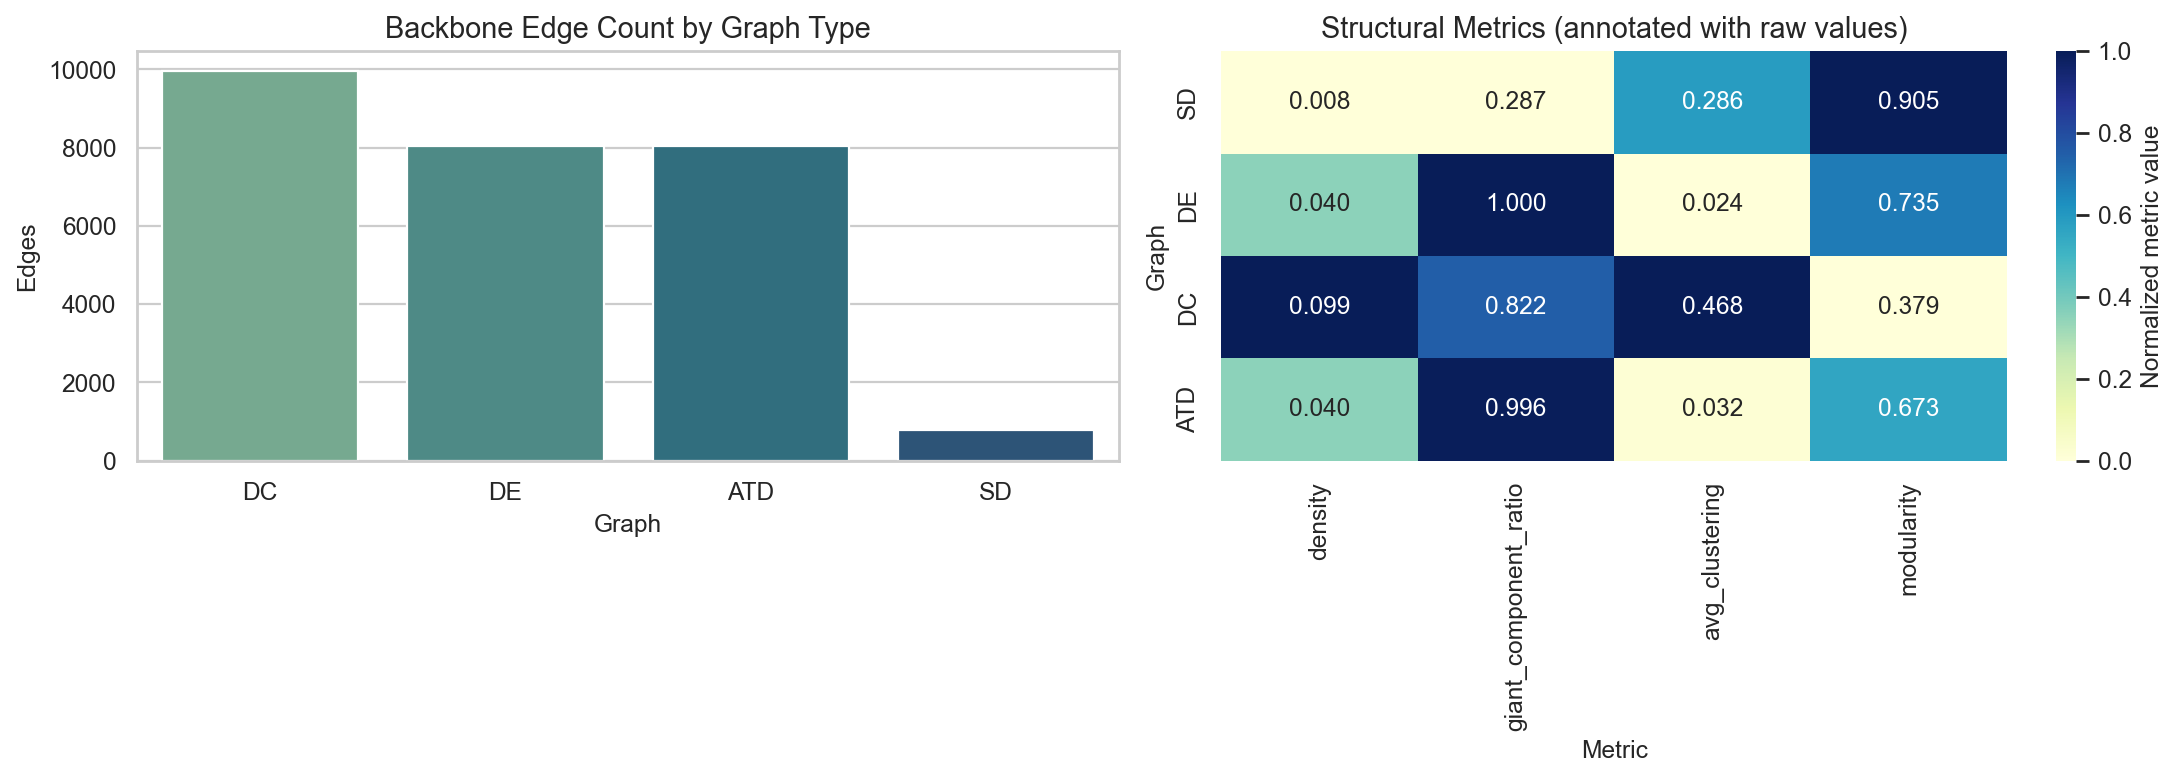

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\multigraph_structural_comparison.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\multigraph_structural_metrics.csv


In [24]:
plot_metrics = ['density', 'giant_component_ratio', 'avg_clustering', 'modularity']
plot_data = structural_df[plot_metrics]
plot_norm = (plot_data - plot_data.min()) / (plot_data.max() - plot_data.min() + 1e-12)
annot_values = np.vectorize(lambda x: f'{x:.3f}')(plot_data.to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edge_plot_df = structural_df.reset_index()[['graph', 'edges']].sort_values('edges', ascending=False)
sns.barplot(
    data=edge_plot_df,
    x='graph',
    y='edges',
    hue='graph',
    palette='crest',
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Backbone Edge Count by Graph Type')
axes[0].set_xlabel('Graph')
axes[0].set_ylabel('Edges')

sns.heatmap(
    plot_norm,
    annot=annot_values,
    fmt='',
    cmap='YlGnBu',
    cbar_kws={'label': 'Normalized metric value'},
    ax=axes[1],
)
axes[1].set_title('Structural Metrics (annotated with raw values)')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Graph')

plt.tight_layout()
structural_fig = save_fig('multigraph_structural_comparison.png')
plt.show()

structural_csv = NETWORK_OUT_DIR / 'multigraph_structural_metrics.csv'
structural_df.to_csv(structural_csv)
print(f'Saved figure: {structural_fig}')
print(f'Saved table: {structural_csv}')

### Node Role Stability Across Graph Definitions

This comparison checks whether top stations are robust to graph definition.

How to read:

1. The heatmap shows Spearman rank correlation between PageRank vectors from each graph
2. The consensus hub ranking rewards stations that rank highly across all graphs

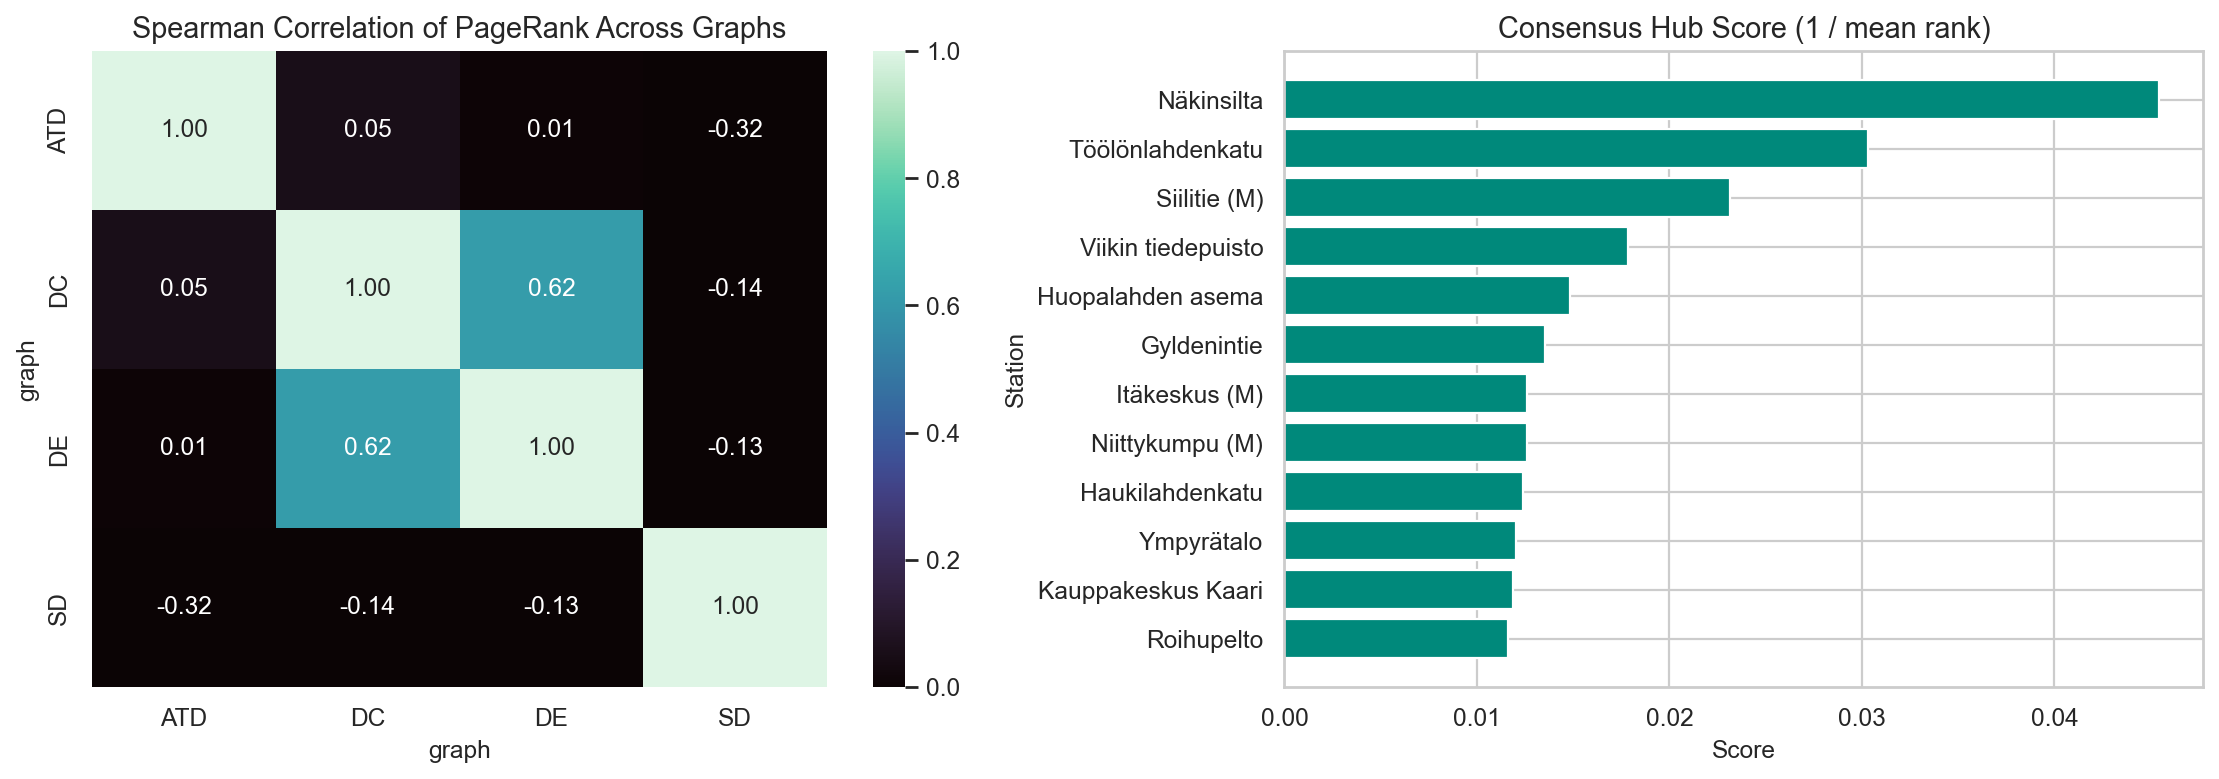

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\multigraph_role_stability.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\multigraph_pagerank_rank_correlation.csv
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\multigraph_consensus_hubs.csv


,mean_rank,std_rank
station_name,,
Näkinsilta,22.00,14.764823
Töölönlahdenkatu,33.00,36.432586
Siilitie (M),43.25,17.385339
Viikin tiedepuisto,56.00,38.470768
Huopalahden asema,67.50,44.762335
Gyldenintie,74.00,42.949583
Itäkeskus (M),79.25,81.907977
Niittykumpu (M),79.50,100.752171
Haukilahdenkatu,80.75,88.107416


In [25]:
role_rows = []
for graph_name, graph in comparison_graphs.items():
    ug = graph.to_undirected() if isinstance(graph, nx.DiGraph) else graph

    if graph.number_of_edges() > 0:
        pr = nx.pagerank(graph, weight='weight')
    else:
        pr = {n: 0.0 for n in graph.nodes()}

    if ug.number_of_edges() > 0:
        bw_k = min(200, max(10, ug.number_of_nodes() // 2))
        bw = nx.betweenness_centrality(ug, k=bw_k, seed=RANDOM_STATE, weight='cost', normalized=True)
    else:
        bw = {n: 0.0 for n in ug.nodes()}

    for station in station_names:
        role_rows.append(
            {
                'station_name': station,
                'graph': graph_name,
                'pagerank': float(pr.get(station, 0.0)),
                'betweenness': float(bw.get(station, 0.0)),
            }
        )

role_df = pd.DataFrame(role_rows)
pagerank_pivot = role_df.pivot(index='station_name', columns='graph', values='pagerank').fillna(0.0)
rank_corr = pagerank_pivot.corr(method='spearman')

rank_table = pagerank_pivot.rank(ascending=False, method='average')
consensus_hubs = (
    pd.DataFrame(
        {
            'mean_rank': rank_table.mean(axis=1),
            'std_rank': rank_table.std(axis=1),
        }
    )
    .sort_values(['mean_rank', 'std_rank'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(rank_corr, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='mako', ax=axes[0])
axes[0].set_title('Spearman Correlation of PageRank Across Graphs')

hub_plot = consensus_hubs.head(12).sort_values('mean_rank', ascending=False)
axes[1].barh(hub_plot.index, 1.0 / hub_plot['mean_rank'], color='#00897B')
axes[1].set_title('Consensus Hub Score (1 / mean rank)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Station')

plt.tight_layout()
role_fig = save_fig('multigraph_role_stability.png')
plt.show()

rank_corr_csv = NETWORK_OUT_DIR / 'multigraph_pagerank_rank_correlation.csv'
rank_corr.to_csv(rank_corr_csv)
consensus_csv = NETWORK_OUT_DIR / 'multigraph_consensus_hubs.csv'
consensus_hubs.to_csv(consensus_csv)

print(f'Saved figure: {role_fig}')
print(f'Saved table: {rank_corr_csv}')
print(f'Saved table: {consensus_csv}')
consensus_hubs.head(15)

### Community Agreement Across Graph Definitions

We run Louvain on each graph backbone and compare partitions with normalized mutual information (NMI).

How to read:

1. NMI near 1 means very similar community assignments
2. Lower NMI indicates each graph captures a different structural signal

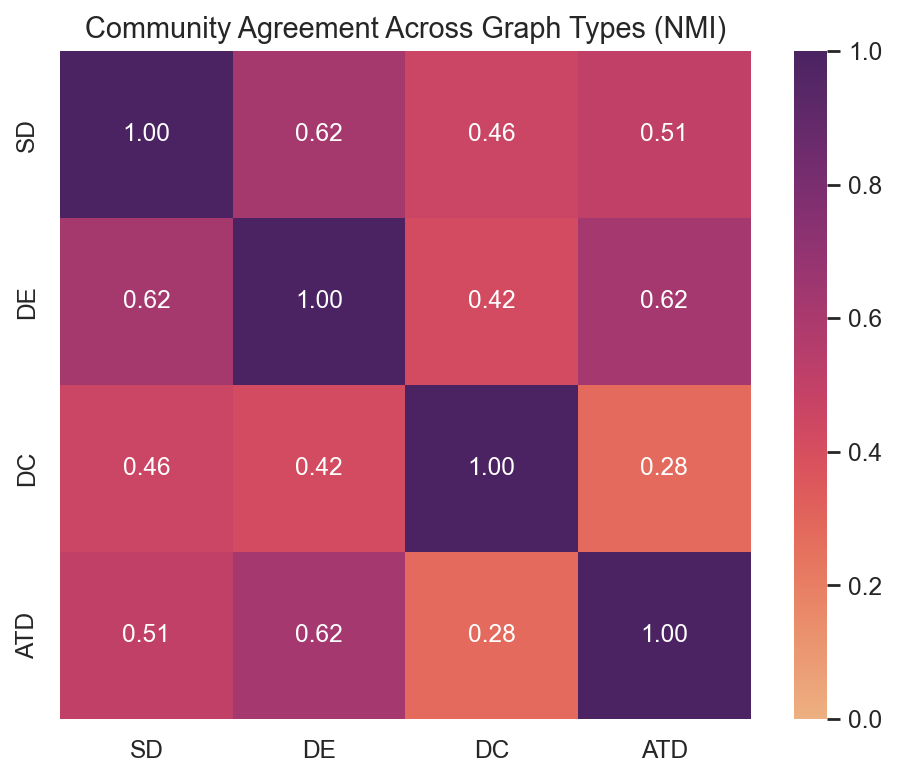

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\multigraph_community_nmi.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\multigraph_community_nmi.csv


,SD,DE,DC,ATD
SD,1.000000,0.618008,0.457099,0.509426
DE,0.618008,1.000000,0.421120,0.622401
DC,0.457099,0.421120,1.000000,0.277619
ATD,0.509426,0.622401,0.277619,1.000000


In [26]:
from sklearn.metrics import normalized_mutual_info_score

partitions = {}
for graph_name, graph in comparison_graphs.items():
    ug = graph.to_undirected() if isinstance(graph, nx.DiGraph) else graph
    if ug.number_of_edges() == 0:
        partitions[graph_name] = {node: i for i, node in enumerate(station_names)}
        continue

    comms = nx.community.louvain_communities(ug, weight='weight', seed=RANDOM_STATE)
    cmap = {}
    for cid, nodes in enumerate(comms):
        for node in nodes:
            cmap[node] = cid

    for node in station_names:
        if node not in cmap:
            cmap[node] = -1
    partitions[graph_name] = cmap

graph_order = list(partitions.keys())
nmi_matrix = pd.DataFrame(index=graph_order, columns=graph_order, dtype=float)

for g1 in graph_order:
    for g2 in graph_order:
        labels1 = [partitions[g1][node] for node in station_names]
        labels2 = [partitions[g2][node] for node in station_names]
        nmi_matrix.loc[g1, g2] = normalized_mutual_info_score(labels1, labels2)

plt.figure(figsize=(6, 5))
sns.heatmap(nmi_matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='flare')
plt.title('Community Agreement Across Graph Types (NMI)')
plt.tight_layout()
nmi_fig = save_fig('multigraph_community_nmi.png')
plt.show()

nmi_csv = NETWORK_OUT_DIR / 'multigraph_community_nmi.csv'
nmi_matrix.to_csv(nmi_csv)
print(f'Saved figure: {nmi_fig}')
print(f'Saved table: {nmi_csv}')
nmi_matrix

### Edge Agreement and Distance-Demand Relationship

This block quantifies how similar the strongest links are across graph types and checks whether spatial affinity (SD) aligns with demand links (DE).

How to read:

1. Jaccard overlap near 1 means two graph views prioritize similar strongest edges
2. Positive SD-DE association suggests geographic closeness supports demand connectivity

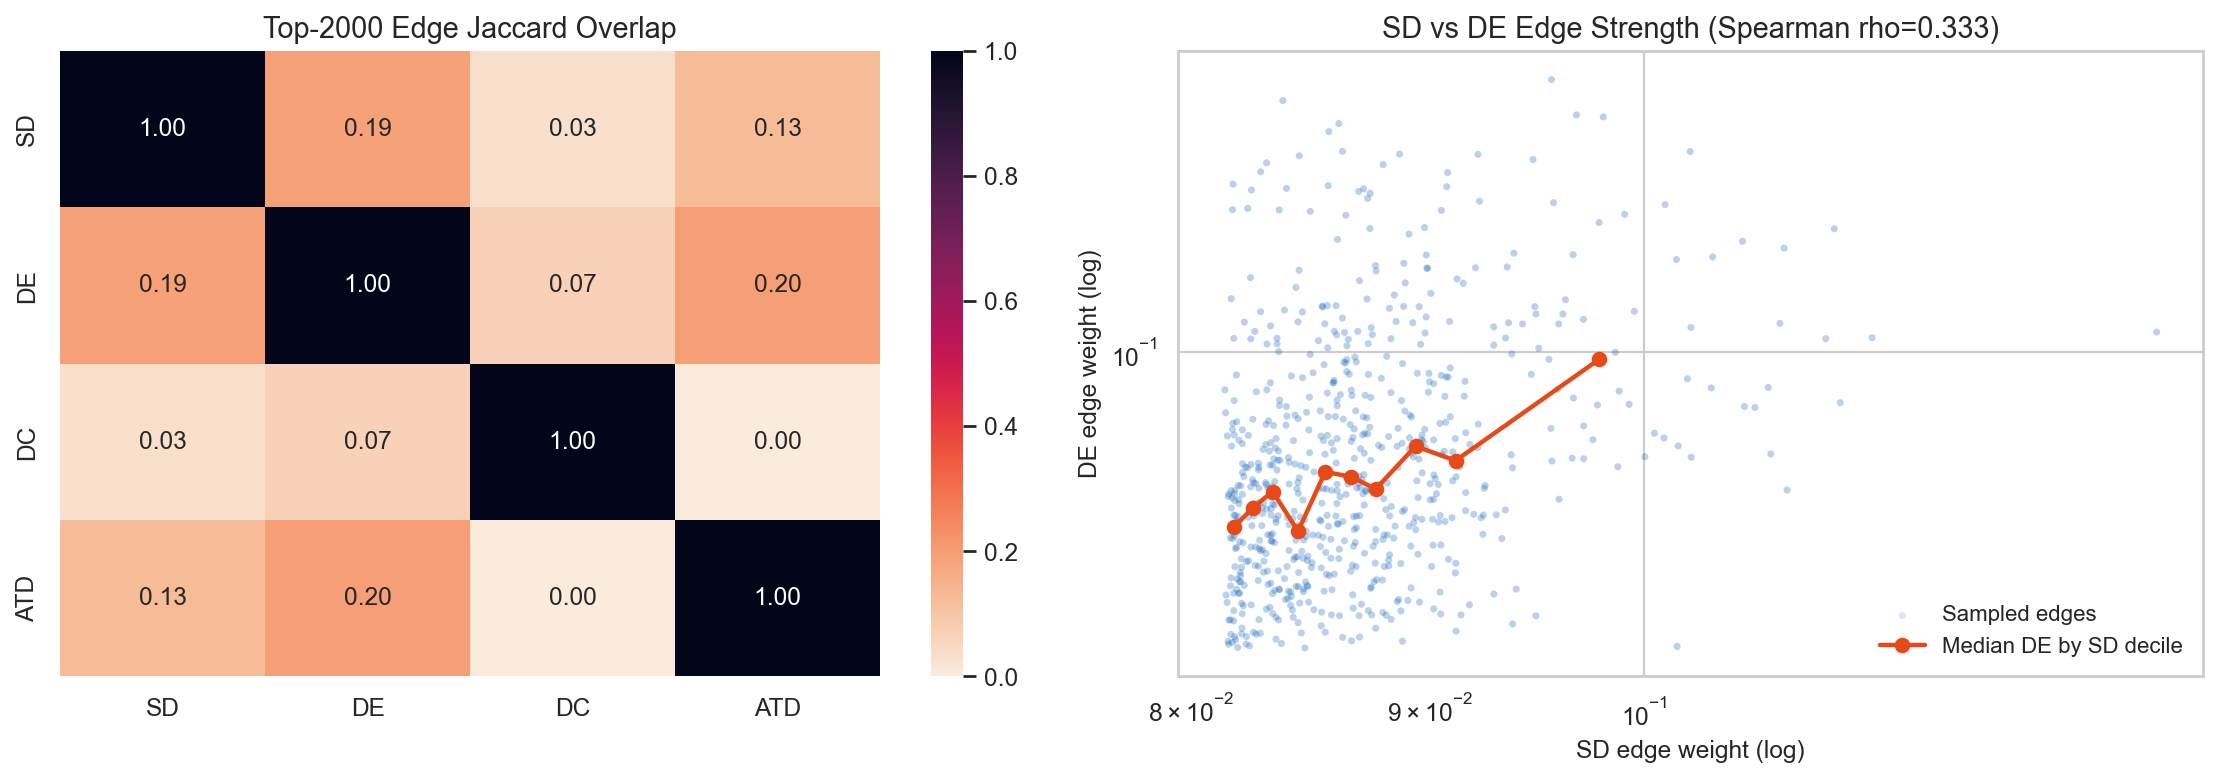

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\multigraph_edge_overlap_and_sd_de_relationship.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\multigraph_edge_jaccard.csv
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\sd_de_edge_relationship.csv
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\sd_de_edge_relationship_deciles.csv


In [27]:
def symmetrize_for_overlap(matrix: np.ndarray) -> np.ndarray:
    m = np.array(matrix, copy=True, dtype=float)
    np.fill_diagonal(m, 0.0)
    return np.maximum(m, m.T)


def top_k_edge_set(matrix: np.ndarray, k: int) -> set[tuple[int, int]]:
    tri_i, tri_j = np.triu_indices_from(matrix, k=1)
    weights = matrix[tri_i, tri_j]
    valid = np.where(weights > 0)[0]
    if valid.size == 0:
        return set()

    if valid.size > k:
        top_idx = valid[np.argpartition(weights[valid], -k)[-k:]]
    else:
        top_idx = valid

    return {(int(tri_i[idx]), int(tri_j[idx])) for idx in top_idx}


sym_mats = {name: symmetrize_for_overlap(backbone_matrices[name]) for name in backbone_matrices}

top_k = 2000
edge_sets = {name: top_k_edge_set(sym_mats[name], k=top_k) for name in sym_mats}

jaccard = pd.DataFrame(index=sym_mats.keys(), columns=sym_mats.keys(), dtype=float)
for g1 in sym_mats:
    for g2 in sym_mats:
        a, b = edge_sets[g1], edge_sets[g2]
        jaccard.loc[g1, g2] = len(a & b) / max(1, len(a | b))

sd = sym_mats['SD']
de = sym_mats['DE']
mask = (sd > 0) & (de > 0)
x = sd[mask]
y = de[mask]

sd_de_df = pd.DataFrame({'sd_weight': x, 'de_weight': y})
sd_de_rho = sd_de_df['sd_weight'].corr(sd_de_df['de_weight'], method='spearman') if not sd_de_df.empty else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(jaccard, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='rocket_r', ax=axes[0])
axes[0].set_title(f'Top-{top_k} Edge Jaccard Overlap')

if sd_de_df.empty:
    axes[1].text(0.5, 0.5, 'No overlapping positive SD and DE edges', ha='center', va='center')
    axes[1].set_axis_off()
    trend_df = pd.DataFrame(columns=['sd_mid', 'de_median', 'count'])
else:
    sample_n = min(15000, len(sd_de_df))
    sample_df = sd_de_df.sample(sample_n, random_state=RANDOM_STATE)
    axes[1].scatter(
        sample_df['sd_weight'],
        sample_df['de_weight'],
        s=10,
        alpha=0.16,
        color='#1565C0',
        edgecolors='none',
        label='Sampled edges',
    )

    sd_bins = pd.qcut(sd_de_df['sd_weight'], q=10, duplicates='drop')
    trend_df = (
        sd_de_df
        .groupby(sd_bins)
        .agg(sd_mid=('sd_weight', 'median'), de_median=('de_weight', 'median'), count=('de_weight', 'size'))
        .reset_index(drop=True)
    )

    axes[1].plot(
        trend_df['sd_mid'],
        trend_df['de_median'],
        color='#E64A19',
        marker='o',
        linewidth=2,
        label='Median DE by SD decile',
    )

    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('SD edge weight (log)')
    axes[1].set_ylabel('DE edge weight (log)')
    axes[1].set_title(f'SD vs DE Edge Strength (Spearman rho={sd_de_rho:.3f})')
    axes[1].legend(frameon=False, loc='lower right')

plt.tight_layout()
overlap_fig = save_fig('multigraph_edge_overlap_and_sd_de_relationship.png')
plt.show()

jaccard_csv = NETWORK_OUT_DIR / 'multigraph_edge_jaccard.csv'
jaccard.to_csv(jaccard_csv)
sd_de_csv = NETWORK_OUT_DIR / 'sd_de_edge_relationship.csv'
sd_de_df.to_csv(sd_de_csv, index=False)
sd_de_trend_csv = NETWORK_OUT_DIR / 'sd_de_edge_relationship_deciles.csv'
trend_df.to_csv(sd_de_trend_csv, index=False)

print(f'Saved figure: {overlap_fig}')
print(f'Saved table: {jaccard_csv}')
print(f'Saved table: {sd_de_csv}')
print(f'Saved table: {sd_de_trend_csv}')

## Export Artifacts

In [28]:
centrality_path = NETWORK_OUT_DIR / 'node_metrics.csv'
community_path = NETWORK_OUT_DIR / 'communities.csv'
community_summary_path = NETWORK_OUT_DIR / 'community_summary.csv'
stability_path = NETWORK_OUT_DIR / 'partition_stability.csv'

centrality_df.to_csv(centrality_path, index=False)

communities_df = pd.DataFrame(
    [(station, cid) for station, cid in louvain_map.items()],
    columns=['station_name', 'community']
).sort_values(['community', 'station_name'])
communities_df.to_csv(community_path, index=False)

community_summary_rows = []
for cid in sorted(set(louvain_map.values())):
    members = {n for n, g in louvain_map.items() if g == cid}
    internal_flow = outgoing_flow = incoming_flow = 0.0
    for u, v, data in G.edges(data=True):
        w = float(data.get('flow', 0.0))
        if u in members and v in members:
            internal_flow += w
        elif u in members and v not in members:
            outgoing_flow += w
        elif u not in members and v in members:
            incoming_flow += w
    community_summary_rows.append({
        'community': cid,
        'stations': len(members),
        'internal_flow': internal_flow,
        'outgoing_flow': outgoing_flow,
        'incoming_flow': incoming_flow,
    })

pd.DataFrame(community_summary_rows).sort_values('stations', ascending=False).to_csv(community_summary_path, index=False)

if not stability_df.empty:
    stability_df.to_csv(stability_path, index=False)

print(f'Saved node metrics: {centrality_path}')
print(f'Saved communities: {community_path}')
print(f'Saved community summary: {community_summary_path}')
if not stability_df.empty:
    print(f'Saved temporal stability: {stability_path}')

Saved node metrics: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\node_metrics.csv
Saved communities: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\communities.csv
Saved community summary: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\community_summary.csv
Saved temporal stability: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\partition_stability.csv


## Interpretation

1. Which stations consistently appear as high-centrality hubs across multiple metrics?
- Top PageRank hubs are **Itämerentori**, **Töölönlahdenkatu**, **Kamppi (M)**, and **Ympyrätalo** (`node_metrics.csv`).
- Bridge-like nodes (high betweenness relative to popularity) include **Kalasatama (M)**, **Arabian kauppakeskus**, **Verkatehtaanpuisto**, and **Viikin tiedepuisto** (`centrality_bridge_vs_hub.csv`).
- This suggests a mixed structure: a small set of global transfer hubs plus corridor connectors that disproportionately support flow between sub-networks.

1. Do Louvain communities align with known geographic barriers and municipality structure?
- Broadly yes: communities separate into dense core and peripheral/municipality-linked groups, but with important cross-boundary commuting ties (`communities.csv`, `community_summary.csv`).
- Community sizes are heterogeneous (largest: 111 stations; smallest: 31), and internal flows vary strongly (for example, one community has very high internal flow at ~3.48M), indicating meaningful mesoscale segmentation rather than random partitioning.
- Interpretation: municipality and shoreline/transport barriers matter, but functional demand corridors still connect communities strongly.

1. Are yearly communities stable or drifting (NMI trend)?
- NMI trend increases from **0.64 (2016-2017)** to **0.92 (2019-2020)**, then remains high at **0.85 (2020-2021)** (`partition_stability.csv`).
- This indicates convergence to a relatively stable mesoscale structure after early-system growth, with moderate perturbation around the pandemic period.
- Practical implication: a mostly static community representation is defensible for baseline forecasting, with periodic re-estimation rather than hourly updates.

1. How sensitive is connectivity to targeted hub removals?
- In the current run, removing top PageRank stations up to 10% kept the giant component ratio at **1.0** (network remained fully connected in the weak/undirected sense).
- So the network is topologically robust in connectivity, but this does **not** imply robustness in efficiency: shortest paths, detour costs, and flow concentration can still degrade substantially.
- Recommended follow-up metric for the paper: report post-removal path-length or efficiency changes alongside giant-component size.

1. How do these findings motivate modeling choices for RQ1-RQ3?
- **RQ1 (functional vs geometric graphs):** Strong bridge effects support including demand-driven graphs (DE/DC), not only SD geometry.
- **RQ2 (fusion):** Partial disagreement across graph views and non-trivial community overlap supports multi-graph fusion rather than single-view models.
- **RQ3 (cluster-level robustness):** High but not perfect temporal stability supports community-level aggregation for sparse stations, while preserving station-level modeling for hub-rich core areas.

## Completeness Assessment (vs similar studies)

Relative to typical city-bike network studies, this notebook is **above average** in scope: it already includes centrality, communities, temporal stability, resilience, and multi-graph comparison.

What is still missing for a publication-grade "complete" network analysis section:
- Uncertainty/significance (bootstrap CIs or permutation tests for centrality/community stability differences).
- Sensitivity analysis for backbone thresholds (quantiles) and Louvain resolution.
- Additional resilience metrics beyond giant component (global efficiency/path-length under attacks).
- Explicit benchmark comparison table against 2-3 prior Helsinki/European bike-network studies.

## Robustness Extensions: Uncertainty, Sensitivity, and Resilience Quality

This section adds three publication-grade robustness analyses:

1. Confidence/uncertainty estimates via bootstrap.
2. Sensitivity to edge-threshold quantiles and Louvain resolution.
3. Resilience quality metrics beyond connectivity (efficiency and path-length degradation).

All outputs are exported to `data/artifacts/network/notebook/` for reporting.

### 1) Confidence and Uncertainty (Bootstrap)

We use a **Poisson bootstrap on OD edge flows** to estimate uncertainty for key station centralities and Louvain modularity.

Rationale: for weighted flow networks, Poisson reweighting gives stable uncertainty bands without repeatedly resampling millions of trip rows.

In [29]:
# Bootstrap uncertainty for centrality and modularity
BOOTSTRAP_N = 100
BOOTSTRAP_SEED = 42
TOP_K_UNCERTAINTY = 15

def build_graph_from_flow_df(flow_df: pd.DataFrame) -> nx.DiGraph:
    g = nx.DiGraph()
    for _, row in flow_df.iterrows():
        src = row['departure_name']
        dst = row['return_name']
        if src == dst:
            continue
        weight = float(row['flow'])
        if weight <= 0:
            continue
        g.add_edge(src, dst, flow=weight, cost=1.0 / max(weight, 1e-9))
    return g

def poisson_bootstrap_flow(flow_df: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    out = flow_df.copy()
    out['flow'] = rng.poisson(out['flow'].to_numpy(dtype=float))
    return out[out['flow'] > 0].reset_index(drop=True)

# Build flow table once from trip-level rows
base_flow_pd = pd.DataFrame(flow_df.to_dicts())
top_stations = centrality_df.head(TOP_K_UNCERTAINTY)['station_name'].tolist()

records = []
modularity_samples = []
rng = np.random.default_rng(BOOTSTRAP_SEED)

for b in range(BOOTSTRAP_N):
    flow_b = poisson_bootstrap_flow(base_flow_pd, rng)
    G_b = build_graph_from_flow_df(flow_b)
    if G_b.number_of_nodes() == 0 or G_b.number_of_edges() == 0:
        continue

    UG_b = G_b.to_undirected()
    pr_b = nx.pagerank(G_b, weight='flow')
    bw_k = min(BETWEENNESS_SAMPLE_K, max(10, UG_b.number_of_nodes() // 2))
    bw_b = nx.betweenness_centrality(UG_b, k=bw_k, seed=BOOTSTRAP_SEED + b, weight='cost', normalized=True)

    for station in top_stations:
        records.append({
            'bootstrap_id': b,
            'station_name': station,
            'pagerank': float(pr_b.get(station, 0.0)),
            'betweenness': float(bw_b.get(station, 0.0)),
        })

    try:
        comms_b = nx.community.louvain_communities(UG_b, weight='flow', seed=BOOTSTRAP_SEED + b, resolution=1.0)
        mod_b = nx.community.modularity(UG_b, comms_b, weight='flow')
        modularity_samples.append(mod_b)
    except Exception:
        pass

bootstrap_df = pd.DataFrame(records)
if bootstrap_df.empty:
    raise RuntimeError('Bootstrap produced no samples. Check graph construction inputs.')

ci_df = (
    bootstrap_df
    .groupby('station_name', as_index=False)
    .agg(
        pagerank_mean=('pagerank', 'mean'),
        pagerank_low=('pagerank', lambda x: np.quantile(x, 0.025)),
        pagerank_high=('pagerank', lambda x: np.quantile(x, 0.975)),
        betweenness_mean=('betweenness', 'mean'),
        betweenness_low=('betweenness', lambda x: np.quantile(x, 0.025)),
        betweenness_high=('betweenness', lambda x: np.quantile(x, 0.975)),
    )
    .merge(centrality_df[['station_name', 'pagerank', 'betweenness']], on='station_name', how='left')
    .sort_values('pagerank', ascending=False)
    .reset_index(drop=True)
)

modularity_ci = {
    'modularity_point_estimate': float(louvain_modularity),
    'modularity_bootstrap_mean': float(np.mean(modularity_samples)) if modularity_samples else np.nan,
    'modularity_bootstrap_low': float(np.quantile(modularity_samples, 0.025)) if modularity_samples else np.nan,
    'modularity_bootstrap_high': float(np.quantile(modularity_samples, 0.975)) if modularity_samples else np.nan,
    'n_bootstrap_success': int(len(modularity_samples)),
}

display(ci_df.head(12))
modularity_ci

,station_name,pagerank_mean,pagerank_low,pagerank_high,betweenness_mean,betweenness_low,betweenness_high,pagerank,betweenness
0,Itämerentori,0.013636,0.013583,0.013675,0.224066,0.199425,0.268398,0.013633,0.244821
1,Töölönlahdenkatu,0.010569,0.010525,0.010609,0.121771,0.106922,0.146119,0.010572,0.132405
2,Kamppi (M),0.008301,0.008265,0.008337,0.010586,0.005323,0.016582,0.008299,0.007105
3,Ympyrätalo,0.008238,0.008206,0.008268,0.023179,0.015698,0.031417,0.008237,0.016672
4,Suomenlahdentie,0.008229,0.008158,0.008302,0.022968,0.011600,0.031865,0.008228,0.021644
5,Kalasatama (M),0.008012,0.007963,0.008061,0.450192,0.429262,0.470296,0.008009,0.437534
6,Rautatientori / länsi,0.007842,0.007814,0.007879,0.147280,0.086741,0.183519,0.007841,0.139905
7,Rautatientori / itä,0.007272,0.007241,0.007312,0.026818,0.017506,0.036066,0.007271,0.027718
8,Sörnäinen (M),0.006931,0.006900,0.006961,0.103540,0.088823,0.140778,0.006934,0.115895
9,Arabian kauppakeskus,0.006874,0.006830,0.006915,0.355129,0.306980,0.418821,0.006873,0.381505


{'modularity_point_estimate': 0.39970241154063074,
 'modularity_bootstrap_mean': 0.4002174540871539,
 'modularity_bootstrap_low': 0.39286611078059175,
 'modularity_bootstrap_high': 0.4056470332404885,
 'n_bootstrap_success': 100}

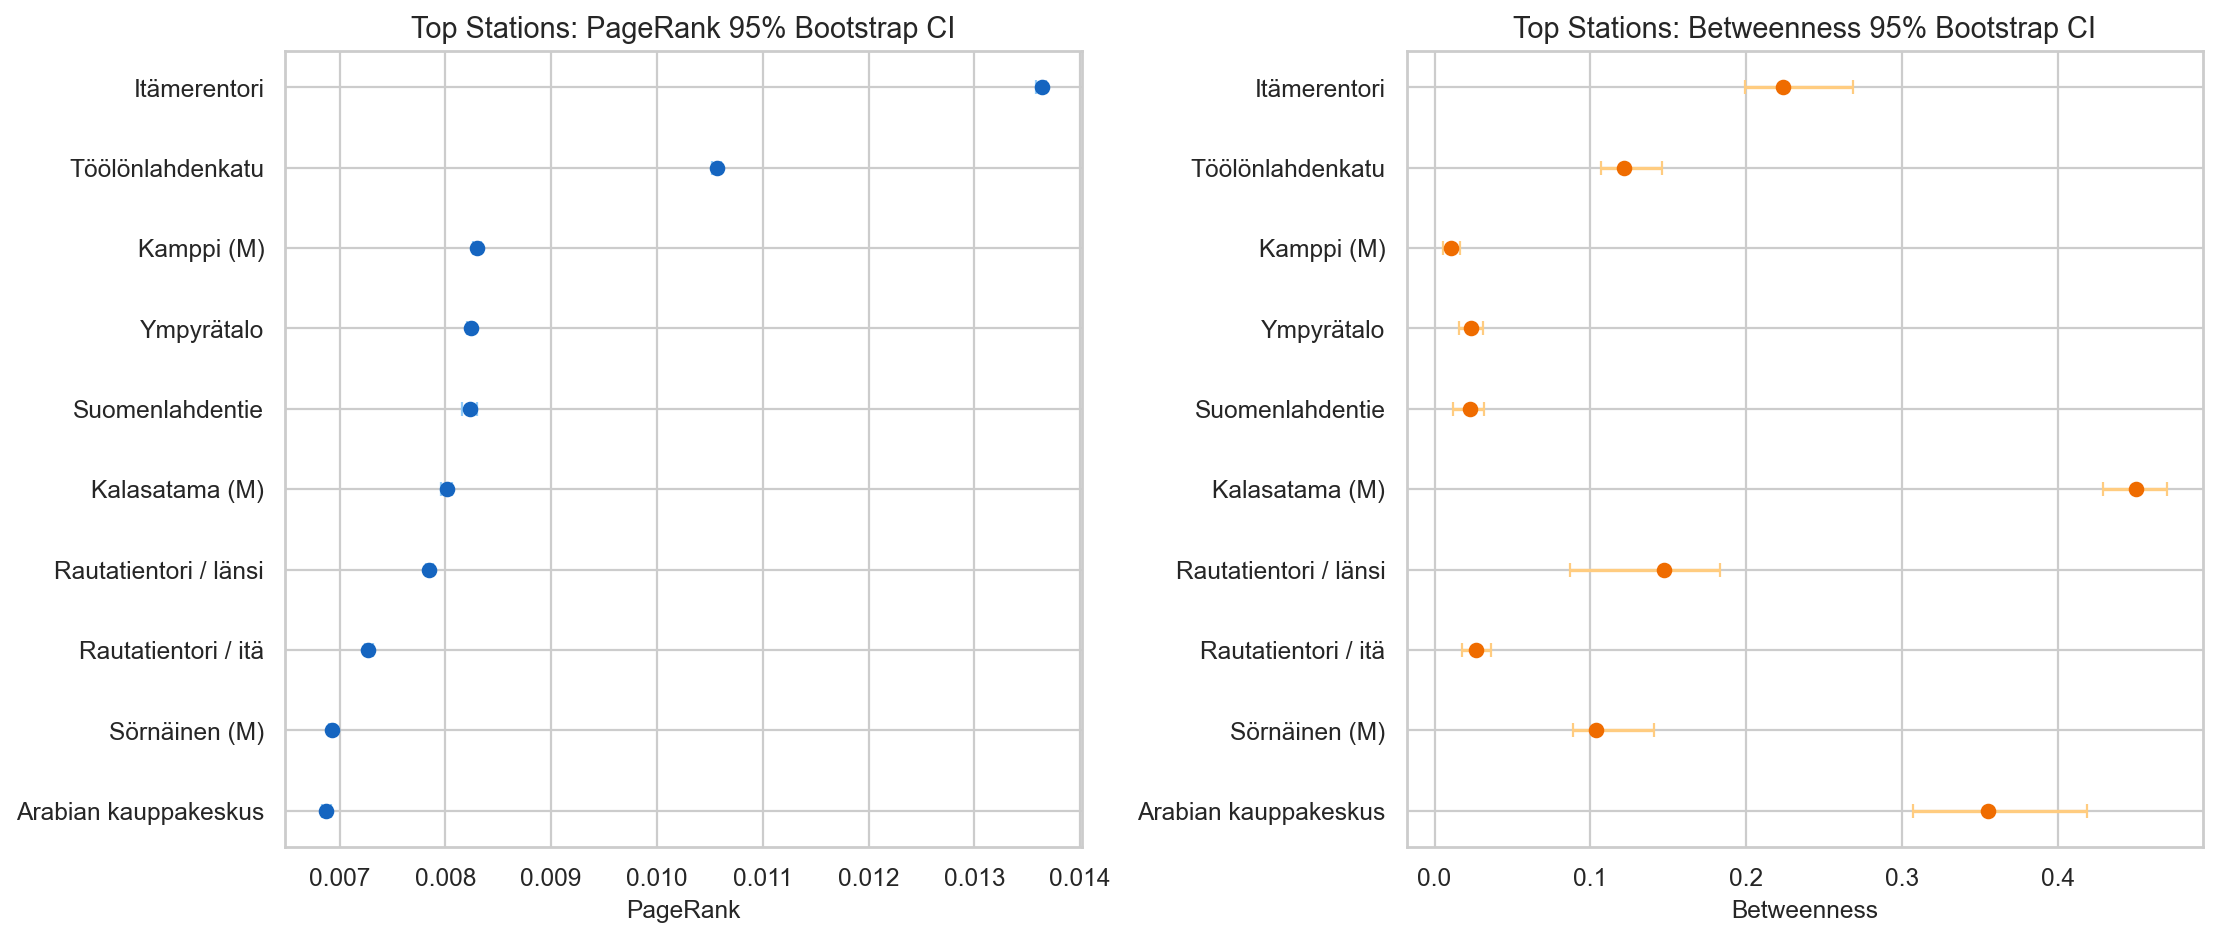

Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\centrality_bootstrap_ci.csv
Saved JSON: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\modularity_bootstrap_ci.json
Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\centrality_bootstrap_ci.png


In [30]:
# Export and visualize bootstrap confidence intervals
bootstrap_ci_csv = NETWORK_OUT_DIR / 'centrality_bootstrap_ci.csv'
ci_df.to_csv(bootstrap_ci_csv, index=False)

modularity_ci_path = NETWORK_OUT_DIR / 'modularity_bootstrap_ci.json'
modularity_ci_path.write_text(pd.Series(modularity_ci).to_json(indent=2), encoding='utf-8')

plot_ci = ci_df.head(10).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].errorbar(
    x=plot_ci['pagerank_mean'],
    y=plot_ci['station_name'],
    xerr=[plot_ci['pagerank_mean'] - plot_ci['pagerank_low'], plot_ci['pagerank_high'] - plot_ci['pagerank_mean']],
    fmt='o',
    color='#1565C0',
    ecolor='#90CAF9',
    capsize=3,
    label='Bootstrap 95% CI',
)
axes[0].set_title('Top Stations: PageRank 95% Bootstrap CI')
axes[0].set_xlabel('PageRank')

axes[1].errorbar(
    x=plot_ci['betweenness_mean'],
    y=plot_ci['station_name'],
    xerr=[plot_ci['betweenness_mean'] - plot_ci['betweenness_low'], plot_ci['betweenness_high'] - plot_ci['betweenness_mean']],
    fmt='o',
    color='#EF6C00',
    ecolor='#FFCC80',
    capsize=3,
    label='Bootstrap 95% CI',
)
axes[1].set_title('Top Stations: Betweenness 95% Bootstrap CI')
axes[1].set_xlabel('Betweenness')

plt.tight_layout()
bootstrap_fig = save_fig('centrality_bootstrap_ci.png')
plt.show()

print(f'Saved table: {bootstrap_ci_csv}')
print(f'Saved JSON: {modularity_ci_path}')
print(f'Saved figure: {bootstrap_fig}')

### 2) Sensitivity to Thresholding and Louvain Resolution

We test how community outcomes change across a grid of backbone quantiles and Louvain `resolution` values.

Reported metrics: community count, modularity, and NMI versus the baseline setting `(quantile=0.90, resolution=1.0)` for each graph.

In [31]:
SENS_QUANTILES = [0.80, 0.85, 0.90, 0.95]
SENS_RESOLUTIONS = [0.8, 1.0, 1.2, 1.4]

sensitivity_rows = []
baseline_partition = {}

for graph_name, matrix in matrices.items():
    # Baseline partition for graph-specific NMI comparisons
    base_backbone = build_backbone_matrix(matrix, quantile=0.90)
    base_graph = matrix_to_graph(base_backbone, station_names, GRAPH_SPECS[graph_name]['directed'])
    base_ug = base_graph.to_undirected() if isinstance(base_graph, nx.DiGraph) else base_graph
    base_comms = nx.community.louvain_communities(base_ug, weight='weight', seed=RANDOM_STATE, resolution=1.0)
    base_map = {}
    for cid, nodes in enumerate(base_comms):
        for node in nodes:
            base_map[node] = cid
    for node in station_names:
        base_map.setdefault(node, -1)
    baseline_partition[graph_name] = base_map

    for q in SENS_QUANTILES:
        backbone = build_backbone_matrix(matrix, quantile=q)
        graph_q = matrix_to_graph(backbone, station_names, GRAPH_SPECS[graph_name]['directed'])
        ug_q = graph_q.to_undirected() if isinstance(graph_q, nx.DiGraph) else graph_q

        if ug_q.number_of_nodes() == 0 or ug_q.number_of_edges() == 0:
            for r in SENS_RESOLUTIONS:
                sensitivity_rows.append({
                    'graph': graph_name,
                    'quantile': q,
                    'resolution': r,
                    'community_count': 0,
                    'modularity': np.nan,
                    'nmi_vs_baseline': np.nan,
                })
            continue

        for r in SENS_RESOLUTIONS:
            comms = nx.community.louvain_communities(ug_q, weight='weight', seed=RANDOM_STATE, resolution=r)
            modularity = nx.community.modularity(ug_q, comms, weight='weight')

            cmap = {}
            for cid, nodes in enumerate(comms):
                for node in nodes:
                    cmap[node] = cid
            for node in station_names:
                cmap.setdefault(node, -1)

            labels_cur = [cmap[node] for node in station_names]
            labels_base = [baseline_partition[graph_name][node] for node in station_names]
            nmi = normalized_mutual_info_score(labels_base, labels_cur)

            sensitivity_rows.append({
                'graph': graph_name,
                'quantile': q,
                'resolution': r,
                'community_count': int(len(comms)),
                'modularity': float(modularity),
                'nmi_vs_baseline': float(nmi),
            })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.head(12))

,graph,quantile,resolution,community_count,modularity,nmi_vs_baseline
0,SD,0.80,0.8,44,0.874254,0.769703
1,SD,0.80,1.0,48,0.878168,0.798159
2,SD,0.80,1.2,49,0.875671,0.814069
3,SD,0.80,1.4,51,0.876378,0.830521
4,SD,0.85,0.8,96,0.905518,0.885802
5,SD,0.85,1.0,96,0.904880,0.879484
6,SD,0.85,1.2,97,0.905731,0.880877
7,SD,0.85,1.4,97,0.905756,0.884689
8,SD,0.90,0.8,170,0.935107,0.996355
9,SD,0.90,1.0,171,0.935263,1.000000


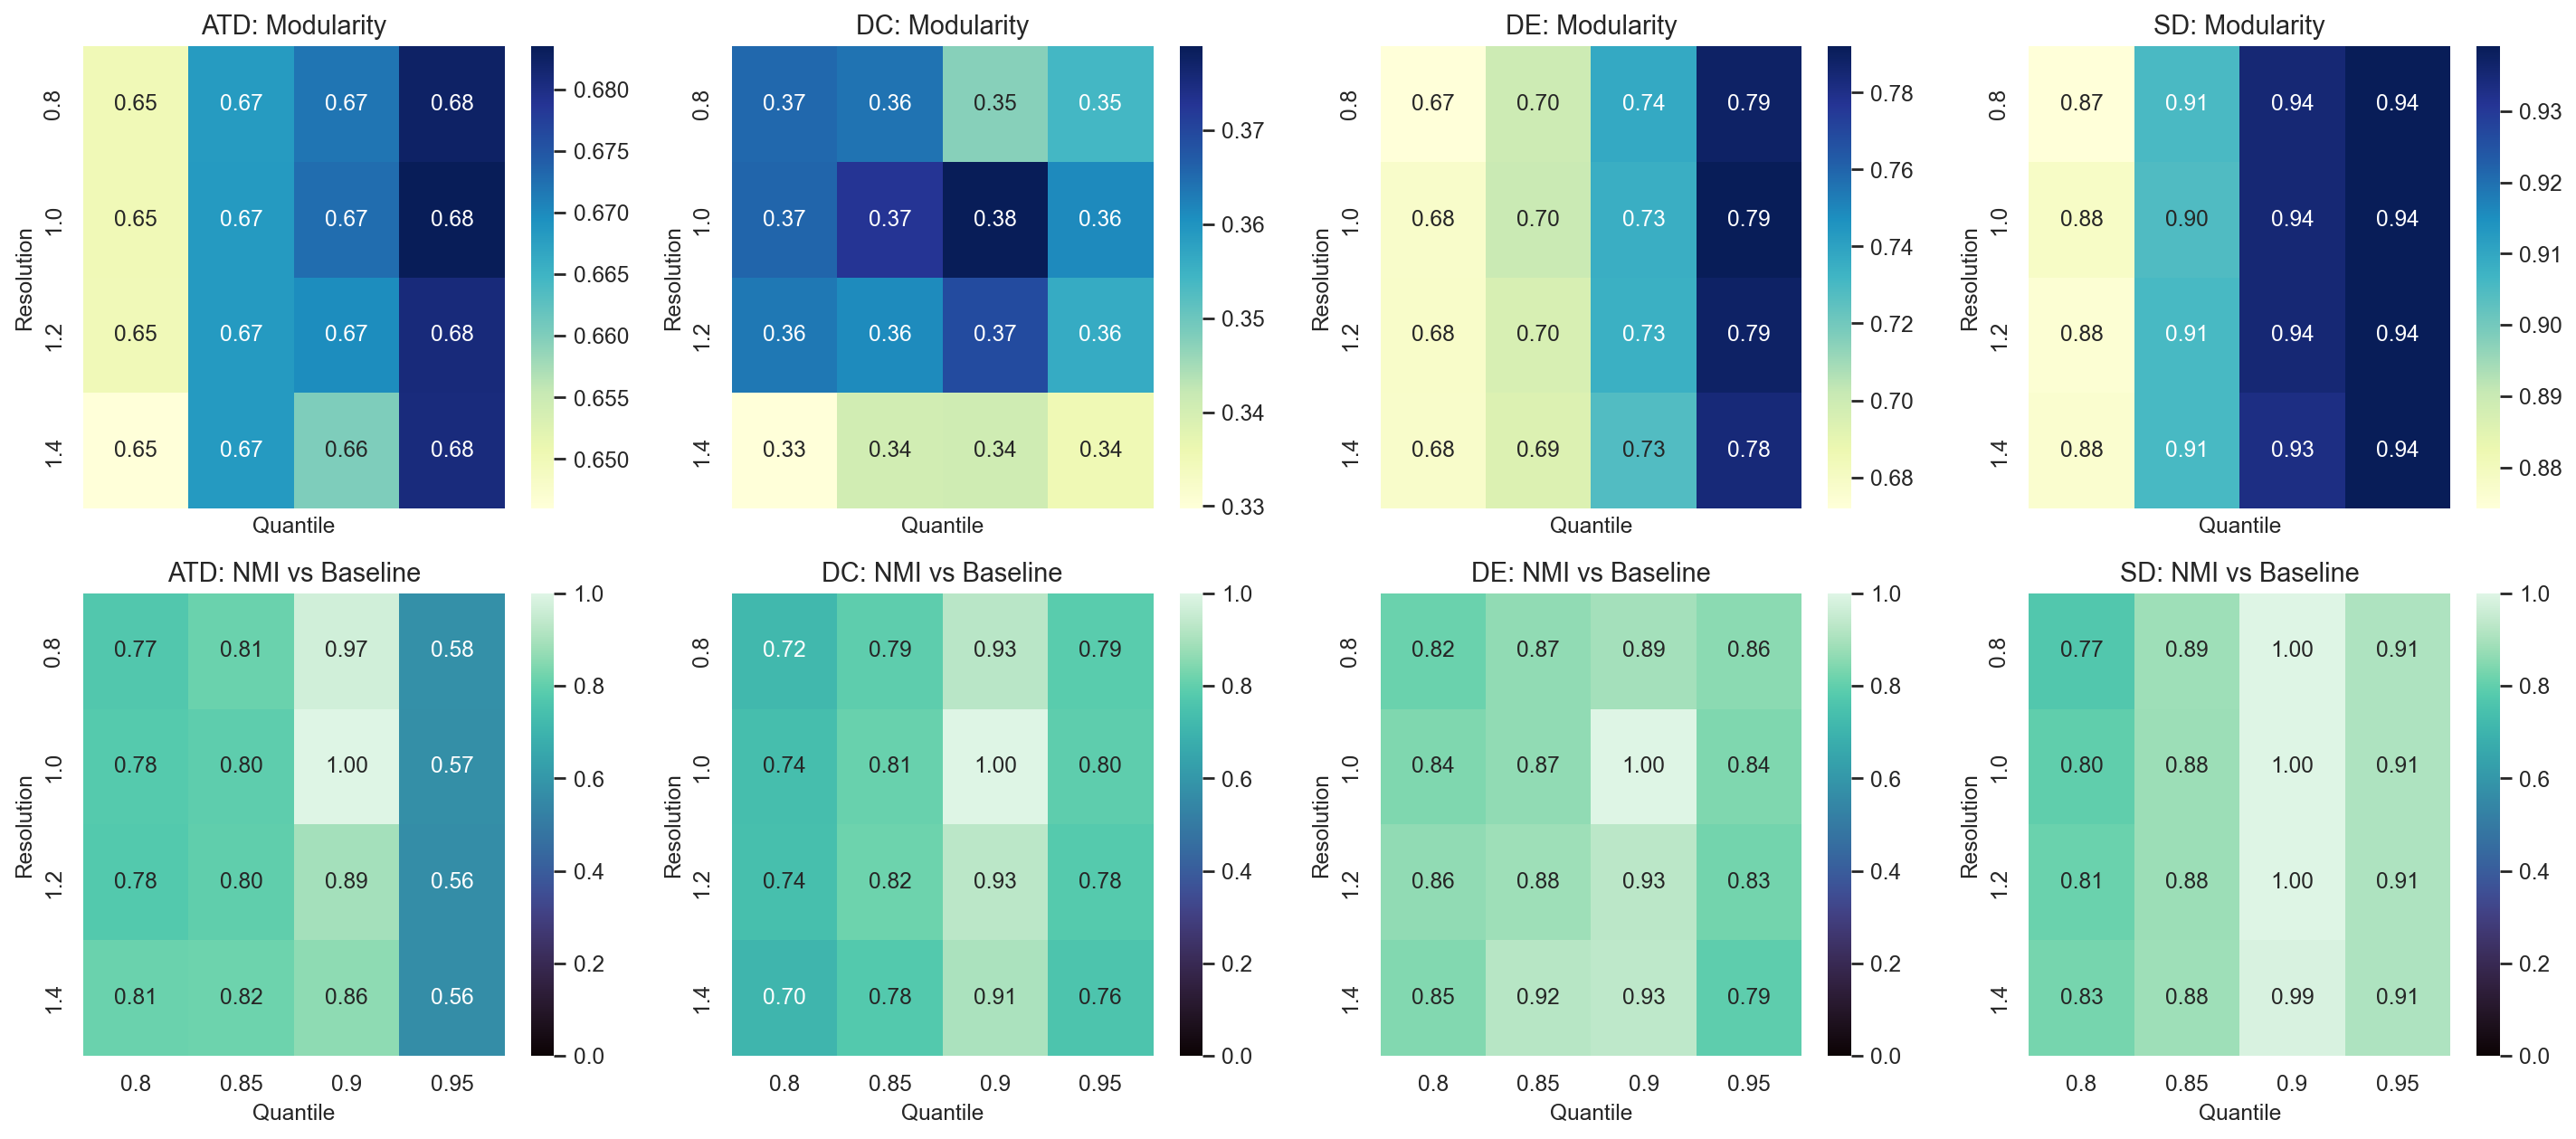

Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\multigraph_threshold_resolution_sensitivity.csv
Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\threshold_resolution_sensitivity_heatmaps.png


In [32]:
sensitivity_csv = NETWORK_OUT_DIR / 'multigraph_threshold_resolution_sensitivity.csv'
sensitivity_df.to_csv(sensitivity_csv, index=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=False)
for idx, graph_name in enumerate(sorted(sensitivity_df['graph'].unique())):
    sub = sensitivity_df[sensitivity_df['graph'] == graph_name]
    mod_pivot = sub.pivot(index='resolution', columns='quantile', values='modularity').sort_index()
    nmi_pivot = sub.pivot(index='resolution', columns='quantile', values='nmi_vs_baseline').sort_index()

    sns.heatmap(mod_pivot, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0, idx])
    axes[0, idx].set_title(f'{graph_name}: Modularity')
    axes[0, idx].set_xlabel('Quantile')
    axes[0, idx].set_ylabel('Resolution')

    sns.heatmap(nmi_pivot, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='mako', ax=axes[1, idx])
    axes[1, idx].set_title(f'{graph_name}: NMI vs Baseline')
    axes[1, idx].set_xlabel('Quantile')
    axes[1, idx].set_ylabel('Resolution')

plt.tight_layout()
sensitivity_fig = save_fig('threshold_resolution_sensitivity_heatmaps.png')
plt.show()

print(f'Saved table: {sensitivity_csv}')
print(f'Saved figure: {sensitivity_fig}')

### 3) Resilience Quality Beyond Connectivity

This section extends resilience analysis beyond giant component size to include:

1. **Weighted global efficiency ratio** (relative to baseline).
2. **Weighted average shortest path ratio** on the giant component.
3. Comparison of **targeted attack** (top PageRank) vs **random removal** (with uncertainty band).

In [33]:
RESILIENCE_FRACTIONS = [0.0, 0.01, 0.02, 0.05, 0.1]
RANDOM_TRIALS = 30
RESILIENCE_SEED = 42
# Optional approximations for faster runs on CPU.
# Set to an integer like 120 to sample source nodes instead of using all nodes.
IGRAPH_EFFICIENCY_SOURCE_SAMPLES = None
IGRAPH_PATH_SOURCE_SAMPLES = None

try:
    import igraph as ig
except ImportError as exc:
    raise ImportError(
        'python-igraph is required for this cell. Install with: pip install python-igraph'
    ) from exc


def nx_to_igraph_undirected(graph: nx.DiGraph) -> tuple[ig.Graph, dict[str, int]]:
    node_names = list(graph.nodes())
    name_to_idx = {name: idx for idx, name in enumerate(node_names)}

    edges: list[tuple[int, int]] = []
    flows: list[float] = []
    costs: list[float] = []

    for u, v, data in graph.edges(data=True):
        if u == v:
            continue
        i = name_to_idx[u]
        j = name_to_idx[v]
        flow = float(data.get('flow', 0.0))
        cost = float(data.get('cost', 1.0 / max(flow, 1e-9)))

        edges.append((i, j))
        flows.append(flow)
        costs.append(cost)

    g = ig.Graph(n=len(node_names), edges=edges, directed=False)
    g.vs['name'] = node_names

    if g.ecount() > 0:
        g.es['flow'] = flows
        g.es['cost'] = costs
        # Merge opposite-direction duplicates in the undirected projection.
        g.simplify(combine_edges={'flow': 'sum', 'cost': 'min'})

    return g, name_to_idx


def weighted_global_efficiency_igraph(
    g: ig.Graph,
    source_samples: int | None = None,
    seed: int = 42,
) -> float:
    n = g.vcount()
    if n <= 1:
        return 0.0

    all_indices = np.arange(n, dtype=int)
    if source_samples is not None and 0 < source_samples < n:
        rng = np.random.default_rng(seed)
        source_idx = rng.choice(all_indices, size=source_samples, replace=False).tolist()
        denom = source_samples * (n - 1)
    else:
        source_idx = all_indices.tolist()
        denom = n * (n - 1)

    weights = g.es['cost'] if g.ecount() > 0 else None
    dist_rows = g.distances(source=source_idx, target=None, weights=weights, mode='ALL')

    inv_sum = 0.0
    for row_i, row in enumerate(dist_rows):
        src = source_idx[row_i]
        for dst, d in enumerate(row):
            if dst == src:
                continue
            if np.isfinite(d) and d > 0:
                inv_sum += 1.0 / d

    return float(inv_sum / max(1, denom))


def weighted_gcc_path_length_igraph(
    g: ig.Graph,
    source_samples: int | None = None,
    seed: int = 42,
) -> float:
    if g.vcount() <= 1:
        return np.nan

    comps = g.connected_components(mode='weak')
    if len(comps) == 0:
        return np.nan

    gcc = comps.giant()
    if gcc.vcount() <= 1:
        return np.nan

    weights = gcc.es['cost'] if gcc.ecount() > 0 else None

    if source_samples is not None and 0 < source_samples < gcc.vcount():
        rng = np.random.default_rng(seed)
        all_indices = np.arange(gcc.vcount(), dtype=int)
        source_idx = rng.choice(all_indices, size=source_samples, replace=False).tolist()
        dist_rows = gcc.distances(source=source_idx, target=None, weights=weights, mode='ALL')

        vals: list[float] = []
        for row_i, row in enumerate(dist_rows):
            src = source_idx[row_i]
            for dst, d in enumerate(row):
                if dst == src:
                    continue
                if np.isfinite(d):
                    vals.append(float(d))
        return float(np.mean(vals)) if vals else np.nan

    return float(gcc.average_path_length(directed=False, unconn=False, weights=weights))


def giant_component_ratio_igraph(g: ig.Graph) -> float:
    n = g.vcount()
    if n == 0:
        return 0.0

    comps = g.connected_components(mode='weak')
    sizes = comps.sizes()
    if not sizes:
        return 0.0
    return float(max(sizes) / n)


def evaluate_resilience_quality(
    graph: nx.DiGraph,
    fractions: list[float],
    random_trials: int = 30,
    seed: int = 42,
    strategy: str = 'targeted',
    efficiency_source_samples: int | None = None,
    path_source_samples: int | None = None,
) -> pd.DataFrame:
    if strategy not in {'targeted', 'random'}:
        raise ValueError('strategy must be targeted or random')

    ig_base, name_to_idx = nx_to_igraph_undirected(graph)

    base_eff = weighted_global_efficiency_igraph(
        ig_base,
        source_samples=efficiency_source_samples,
        seed=seed,
    )
    base_path = weighted_gcc_path_length_igraph(
        ig_base,
        source_samples=path_source_samples,
        seed=seed,
    )

    pr = nx.pagerank(graph, weight='flow')
    ranked_names = [k for k, _ in sorted(pr.items(), key=lambda x: x[1], reverse=True)]
    ranked_idx = [name_to_idx[name] for name in ranked_names if name in name_to_idx]

    all_idx = np.arange(ig_base.vcount(), dtype=int)
    rng = np.random.default_rng(seed)

    rows = []
    for frac in fractions:
        k_remove = int(np.floor(frac * graph.number_of_nodes()))

        trial_metrics = []
        n_trials = 1 if strategy == 'targeted' else random_trials
        for t in range(n_trials):
            if k_remove > 0:
                if strategy == 'targeted':
                    remove_idx = ranked_idx[:k_remove]
                else:
                    remove_idx = rng.choice(all_idx, size=k_remove, replace=False).tolist()

                remove_set = set(int(x) for x in remove_idx)
                keep_idx = [int(x) for x in all_idx if int(x) not in remove_set]
                g_tmp = ig_base.induced_subgraph(keep_idx)
            else:
                g_tmp = ig_base

            gcc_ratio = giant_component_ratio_igraph(g_tmp)
            eff = weighted_global_efficiency_igraph(
                g_tmp,
                source_samples=efficiency_source_samples,
                seed=seed + t,
            )
            path_len = weighted_gcc_path_length_igraph(
                g_tmp,
                source_samples=path_source_samples,
                seed=seed + t,
            )

            eff_ratio = eff / base_eff if base_eff > 0 else np.nan
            path_ratio = (
                path_len / base_path
                if (
                    base_path is not None
                    and np.isfinite(base_path)
                    and base_path > 0
                    and np.isfinite(path_len)
                )
                else np.nan
            )

            trial_metrics.append((gcc_ratio, eff_ratio, path_ratio))

        arr = np.asarray(trial_metrics, dtype=float)
        rows.append({
            'strategy': strategy,
            'removed_fraction': frac,
            'k_removed': k_remove,
            'giant_component_ratio_mean': float(np.nanmean(arr[:, 0])),
            'giant_component_ratio_low': float(np.nanquantile(arr[:, 0], 0.025)),
            'giant_component_ratio_high': float(np.nanquantile(arr[:, 0], 0.975)),
            'efficiency_ratio_mean': float(np.nanmean(arr[:, 1])),
            'efficiency_ratio_low': float(np.nanquantile(arr[:, 1], 0.025)),
            'efficiency_ratio_high': float(np.nanquantile(arr[:, 1], 0.975)),
            'path_ratio_mean': float(np.nanmean(arr[:, 2])),
            'path_ratio_low': float(np.nanquantile(arr[:, 2], 0.025)),
            'path_ratio_high': float(np.nanquantile(arr[:, 2], 0.975)),
        })

    return pd.DataFrame(rows)


res_targeted = evaluate_resilience_quality(
    graph=G,
    fractions=RESILIENCE_FRACTIONS,
    random_trials=RANDOM_TRIALS,
    seed=RESILIENCE_SEED,
    strategy='targeted',
    efficiency_source_samples=IGRAPH_EFFICIENCY_SOURCE_SAMPLES,
    path_source_samples=IGRAPH_PATH_SOURCE_SAMPLES,
)
res_random = evaluate_resilience_quality(
    graph=G,
    fractions=RESILIENCE_FRACTIONS,
    random_trials=RANDOM_TRIALS,
    seed=RESILIENCE_SEED,
    strategy='random',
    efficiency_source_samples=IGRAPH_EFFICIENCY_SOURCE_SAMPLES,
    path_source_samples=IGRAPH_PATH_SOURCE_SAMPLES,
)

resilience_quality_df = pd.concat([res_targeted, res_random], ignore_index=True)
display(resilience_quality_df)

,strategy,removed_fraction,k_removed,giant_component_ratio_mean,giant_component_ratio_low,giant_component_ratio_high,efficiency_ratio_mean,efficiency_ratio_low,efficiency_ratio_high,path_ratio_mean,path_ratio_low,path_ratio_high
0,targeted,0.00,0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,targeted,0.01,4,1.0,1.0,1.0,0.866356,0.866356,0.866356,1.018844,1.018844,1.018844
2,targeted,0.02,8,1.0,1.0,1.0,0.787589,0.787589,0.787589,1.045419,1.045419,1.045419
3,targeted,0.05,22,1.0,1.0,1.0,0.567624,0.567624,0.567624,1.225872,1.225872,1.225872
4,targeted,0.10,44,1.0,1.0,1.0,0.433233,0.433233,0.433233,1.405154,1.405154,1.405154
5,random,0.00,0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,random,0.01,4,1.0,1.0,1.0,0.993481,0.953210,1.008869,1.008274,0.985238,1.055186
7,random,0.02,8,1.0,1.0,1.0,0.992300,0.957705,1.010046,1.013480,0.986078,1.060141
8,random,0.05,22,1.0,1.0,1.0,0.971172,0.887977,1.019853,1.043943,1.002293,1.107791
9,random,0.10,44,1.0,1.0,1.0,0.942172,0.842059,1.031265,1.079123,0.993348,1.190104


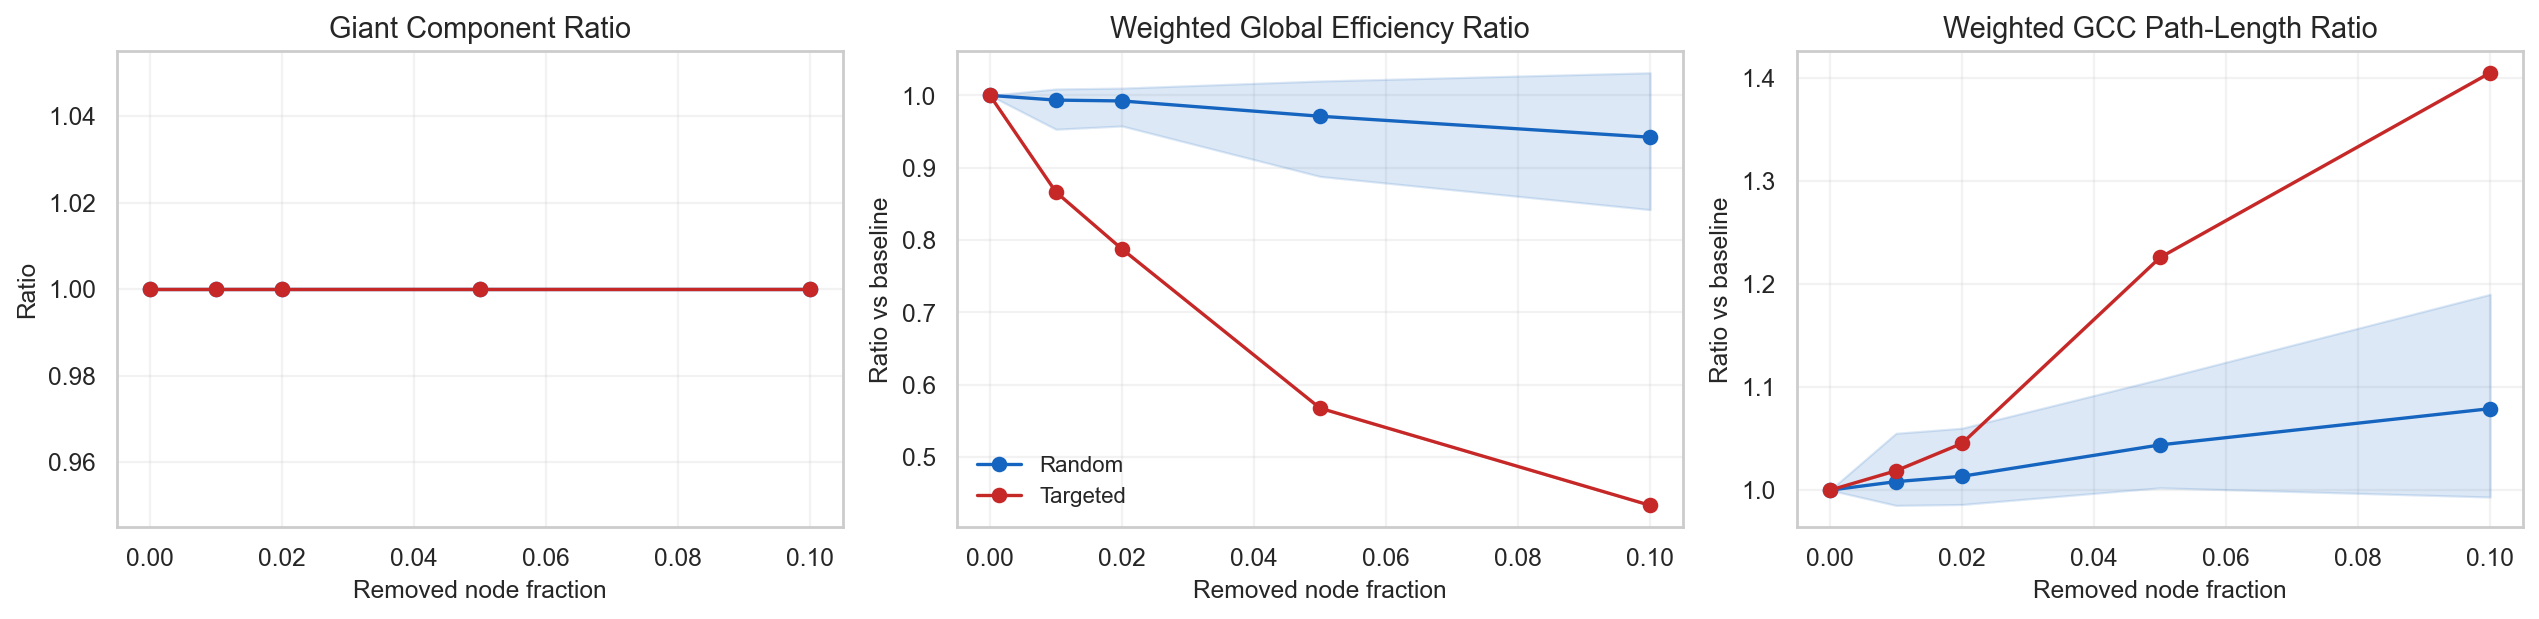

Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\resilience_quality_metrics.csv
Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\artifacts\network\notebook\figures\resilience_quality_metrics.png


In [34]:
resilience_quality_csv = NETWORK_OUT_DIR / 'resilience_quality_metrics.csv'
resilience_quality_df.to_csv(resilience_quality_csv, index=False)

if 'save_fig' not in globals():
    FIG_DIR = NETWORK_OUT_DIR / 'figures'
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    def save_fig(filename: str):
        out = FIG_DIR / filename
        plt.savefig(out, bbox_inches='tight')
        return out

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

palette = {'targeted': '#C62828', 'random': '#1565C0'}
for strategy, sub in resilience_quality_df.groupby('strategy'):
    color = palette.get(strategy, '#455A64')
    axes[0].plot(sub['removed_fraction'], sub['giant_component_ratio_mean'], marker='o', color=color, label=strategy.title())
    axes[0].fill_between(sub['removed_fraction'], sub['giant_component_ratio_low'], sub['giant_component_ratio_high'], color=color, alpha=0.15)

    axes[1].plot(sub['removed_fraction'], sub['efficiency_ratio_mean'], marker='o', color=color, label=strategy.title())
    axes[1].fill_between(sub['removed_fraction'], sub['efficiency_ratio_low'], sub['efficiency_ratio_high'], color=color, alpha=0.15)

    axes[2].plot(sub['removed_fraction'], sub['path_ratio_mean'], marker='o', color=color, label=strategy.title())
    axes[2].fill_between(sub['removed_fraction'], sub['path_ratio_low'], sub['path_ratio_high'], color=color, alpha=0.15)

axes[0].set_title('Giant Component Ratio')
axes[0].set_ylabel('Ratio')
axes[1].set_title('Weighted Global Efficiency Ratio')
axes[1].set_ylabel('Ratio vs baseline')
axes[2].set_title('Weighted GCC Path-Length Ratio')
axes[2].set_ylabel('Ratio vs baseline')

for ax in axes:
    ax.set_xlabel('Removed node fraction')
    ax.grid(alpha=0.25)

axes[1].legend(loc='best', frameon=False)
plt.tight_layout()
resilience_quality_fig = save_fig('resilience_quality_metrics.png')
plt.show()

print(f'Saved table: {resilience_quality_csv}')
print(f'Saved figure: {resilience_quality_fig}')